# PROJET — Prédiction de la Santé Fœtale (CTG)
# Classification multiclasse supervisée : Normal / Suspect / Pathologique

# Prédiction de la Santé Fœtale
## Contexte
La cardiotocographie (CTG) est un outil médical permettant de surveiller
la santé du fœtus pendant la grossesse. Ce projet vise à prédire
automatiquement le niveau de santé fœtale à partir de mesures CTG.
## Objectif
Construire un modèle de **classification multiclasse supervisée** capable
 de prédire l'état de santé fœtale en 3 catégories :
 - **1 - Normal** : état sain
 - **2 - Suspect** : surveillance recommandée
 - **3 - Pathologique** : intervention médicale nécessaire

 ## Dataset
 - **Source** : UCI Machine Learning Repository
 - **Taille** : 2126 lignes × 22 colonnes
 - **Features** : 21 mesures CTG (fréquence cardiaque, accélérations, décélérations...)
 - **Cible** : fetal_health (1 / 2 / 3)
 ## Features 
 | # | Variable | Catégorie | Unité | Description |
|---|---|---|---|---|
| 1 | baseline value | Rythme cardiaque | bpm | Fréquence cardiaque fœtale de base. Plage normale : 110–160 bpm |
| 2 | accelerations | Mouvements & Réactivité | acc/sec | Accélérations soudaines — signe de réactivité et bonne santé |
| 3 | fetal_movement | Mouvements & Réactivité | mv/sec | Nombre de mouvements fœtaux détectés par seconde |
| 4 | uterine_contractions | Mouvements & Réactivité | ct/sec | Contractions utérines par seconde — peuvent stresser le fœtus |
| 5 | light_decelerations | Décélérations | dc/sec | Légères baisses du rythme — préoccupantes en excès |
| 6 | severe_decelerations | Décélérations | dc/sec | Baisses sévères — toujours un signal d'alarme |
| 7 | prolongued_decelerations | Décélérations | dc/sec | Baisses > 2 min — indicateur fort de détresse fœtale |
| 8 | abnormal_short_term_variability | Variabilité | % | % de temps avec variation à court terme anormale |
| 9 | mean_value_of_short_term_variability | Variabilité | ms | Moyenne de la variation à court terme |
| 10 | percentage_of_time_with_abnormal_long_term_variability | Variabilité | % | % de temps avec variabilité à long terme anormale |
| 11 | mean_value_of_long_term_variability | Variabilité | ms | Variation moyenne à long terme du rythme |
| 12 | histogram_width | Histogramme | bpm | Étendue de l'histogramme — plus large = plus sain |
| 13 | histogram_min | Histogramme | bpm | Fréquence cardiaque minimale enregistrée |
| 14 | histogram_number_of_peaks | Histogramme | pics | Nombre de pics — plus de pics = rythme plus complexe |
| 15 | histogram_number_of_zeroes | Histogramme | zéros | Valeurs nulles — beaucoup = rythme plat = mauvais signe |
| 16 | histogram_mean | Histogramme | bpm | Moyenne du rythme sur tout l'enregistrement |
| 17 | histogram_variance | Histogramme | bpm² | Dispersion des valeurs — plus élevée chez les pathologiques |
| 18 | histogram_tendency | Histogramme | -1/0/1 | Asymétrie : gauche (-1), symétrique (0), droite (+1) |
| 19 | variability_score *(créée)* | Feature Engineering | score | Score combiné variabilité court + long terme |
| 20 | histogram_amplitude *(créée)* | Feature Engineering | bpm | Mode − min : faible amplitude = rythme monotone |

# SECTION 1 — CHARGEMENT & EXPLORATION INITIALE

In [5]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

In [6]:
df = pd.read_csv("fetal_health.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

Le dataset CTG (Cardiotocographie) contient 2126 observations et 22 colonnes.
Chaque ligne représente un examen CTG d'une patiente avec 21 mesures du rythme
cardiaque fœtal et une variable cible `fetal_health` indiquant l'état de santé :
- **1 - Normal** : fœtus en bonne santé
- **2 - Suspect** : surveillance recommandée  
- **3 - Pathologique** : intervention médicale nécessaire

In [7]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [8]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


# SECTION 2 — PRÉPROCESSING

### 2.1 Vérification de la qualité des données
On vérifie trois points essentiels avant tout traitement :
- **Valeurs manquantes** → peuvent biaiser l'entraînement des modèles
- **Doublons** → créent une fuite d'information si présents dans train et test
- **Types** → doivent être cohérents avec les algorithmes

In [9]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode     

**Résultat :** Aucune valeur manquante détectée → dataset propre ✅

In [10]:
# Doublons
print(f"Nombre de doublons : {df.duplicated().sum()}")

Nombre de doublons : 13


**Résultat :** 13 doublons détectés. Ils seront supprimés **uniquement du train set**
après le split pour éviter tout data leakage.

### 2.3 Encodage de la variable cible

In [11]:
#La variable cible `fetal_health` est déjà numérique (1.0 / 2.0 / 3.0) On la convertit en entier pour plus de clarté.
df['fetal_health'] = df['fetal_health'].astype(int)
print(df['fetal_health'].value_counts())

fetal_health
1    1655
2     295
3     176
Name: count, dtype: int64


### 2.4 Séparation Features / Cible

In [12]:
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']
print(f"X : {X.shape}")
print(f"y : {y.shape}")

X : (2126, 21)
y : (2126,)


### 2.5 Split stratifié 75/25
Le split est effectué avant toute transformation (suppression de doublons,
normalisation, etc.) pour garantir l'intégrité de l'évaluation.
Le test set ne doit jamais influencer le processus d'entraînement.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"\nDistribution train : {pd.Series(y_train).value_counts().sort_index().to_dict()}")
print(f"Distribution test  : {pd.Series(y_test).value_counts().sort_index().to_dict()}")

Train : (1594, 21)
Test  : (532, 21)

Distribution train : {1: 1241, 2: 221, 3: 132}
Distribution test  : {1: 414, 2: 74, 3: 44}


### 2.6 Suppression des doublons
Les doublons sont supprimés uniquement du train set.
Le test set reste intact pour une évaluation réaliste.

In [14]:
print(f"Avant suppression doublons - Train : {X_train.shape[0]} lignes")

train_df = pd.concat([X_train, pd.Series(y_train, index=X_train.index, name='fetal_health')], axis=1)
train_df = train_df.drop_duplicates()
X_train = train_df.drop('fetal_health', axis=1)
y_train = train_df['fetal_health'].values

print(f"Après suppression doublons - Train : {X_train.shape[0]} lignes")
print(f"Test (inchangé) : {X_test.shape[0]} lignes")

Avant suppression doublons - Train : 1594 lignes
Après suppression doublons - Train : 1587 lignes
Test (inchangé) : 532 lignes


### 2.7 Détection des Outliers

In [15]:
# Méthode IQR (Interquartile Range) pour détecter les valeurs aberrantes
for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = X_train[(X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR)]
    print(f"{col:<55} : {len(outliers)} outliers")

baseline value                                          : 0 outliers
accelerations                                           : 11 outliers
fetal_movement                                          : 234 outliers
uterine_contractions                                    : 0 outliers
light_decelerations                                     : 109 outliers
severe_decelerations                                    : 4 outliers
prolongued_decelerations                                : 139 outliers
abnormal_short_term_variability                         : 0 outliers
mean_value_of_short_term_variability                    : 50 outliers
percentage_of_time_with_abnormal_long_term_variability  : 233 outliers
mean_value_of_long_term_variability                     : 51 outliers
histogram_width                                         : 0 outliers
histogram_min                                           : 0 outliers
histogram_max                                           : 17 outliers
histogram_number_of_pe

**Décision :** Tous les outliers sont conservés.
 - `fetal_movement` (305) et `prolongued_decelerations` (178) → signes cliniques critiques
 - `histogram_number_of_zeroes` (502) → variabilité nulle = état pathologique potentiel
 Supprimer ces valeurs reviendrait à **éliminer les cas les plus dangereux**.

# SECTION 3 — ANALYSE EXPLORATOIRE (EDA)

### 3.1 Distribution de la variable cible

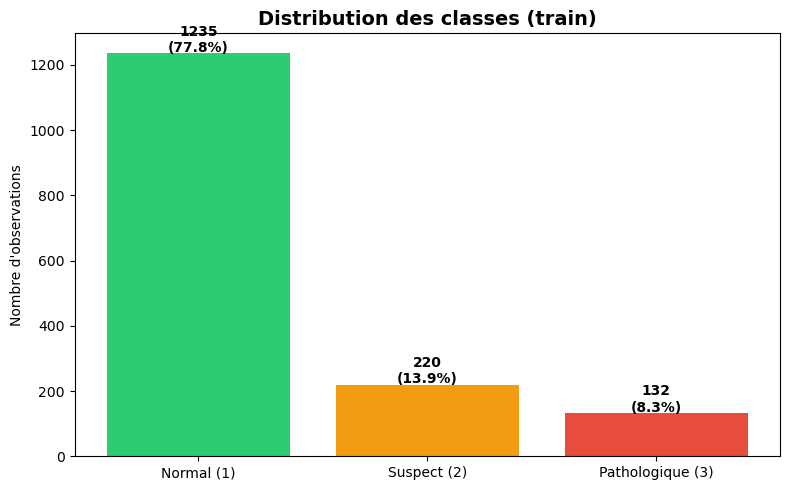

In [16]:
# vérification de l'équilibre des classes.
counts = pd.Series(y_train).value_counts().sort_index()
labels = ['Normal (1)', 'Suspect (2)', 'Pathologique (3)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(8, 5))
plt.bar(labels, counts.values, color=colors)
plt.title("Distribution des classes (train)", fontweight='bold', fontsize=14)
plt.ylabel("Nombre d'observations")
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, f"{v}\n({v/len(y_train)*100:.1f}%)", 
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Résultat :** Déséquilibre important :
- Normal : **77.8%** (1646 cas)
- Suspect : **13.8%** (292 cas)
- Pathologique : **8.3%** (175 cas)
 **Implication :** Sans correction, un modèle naïf prédirait "Normal" pour tout et obtiendrait 77% d'accuracy — **trompeuse et dangereuse cliniquement**.

On utilisera **SMOTE** sur le train set pour rééquilibrer les classes.

### 3.2 Boxplots par classe
Les boxplots permettent de visualiser quelles features séparent bien les 3 classes de santé fœtale.

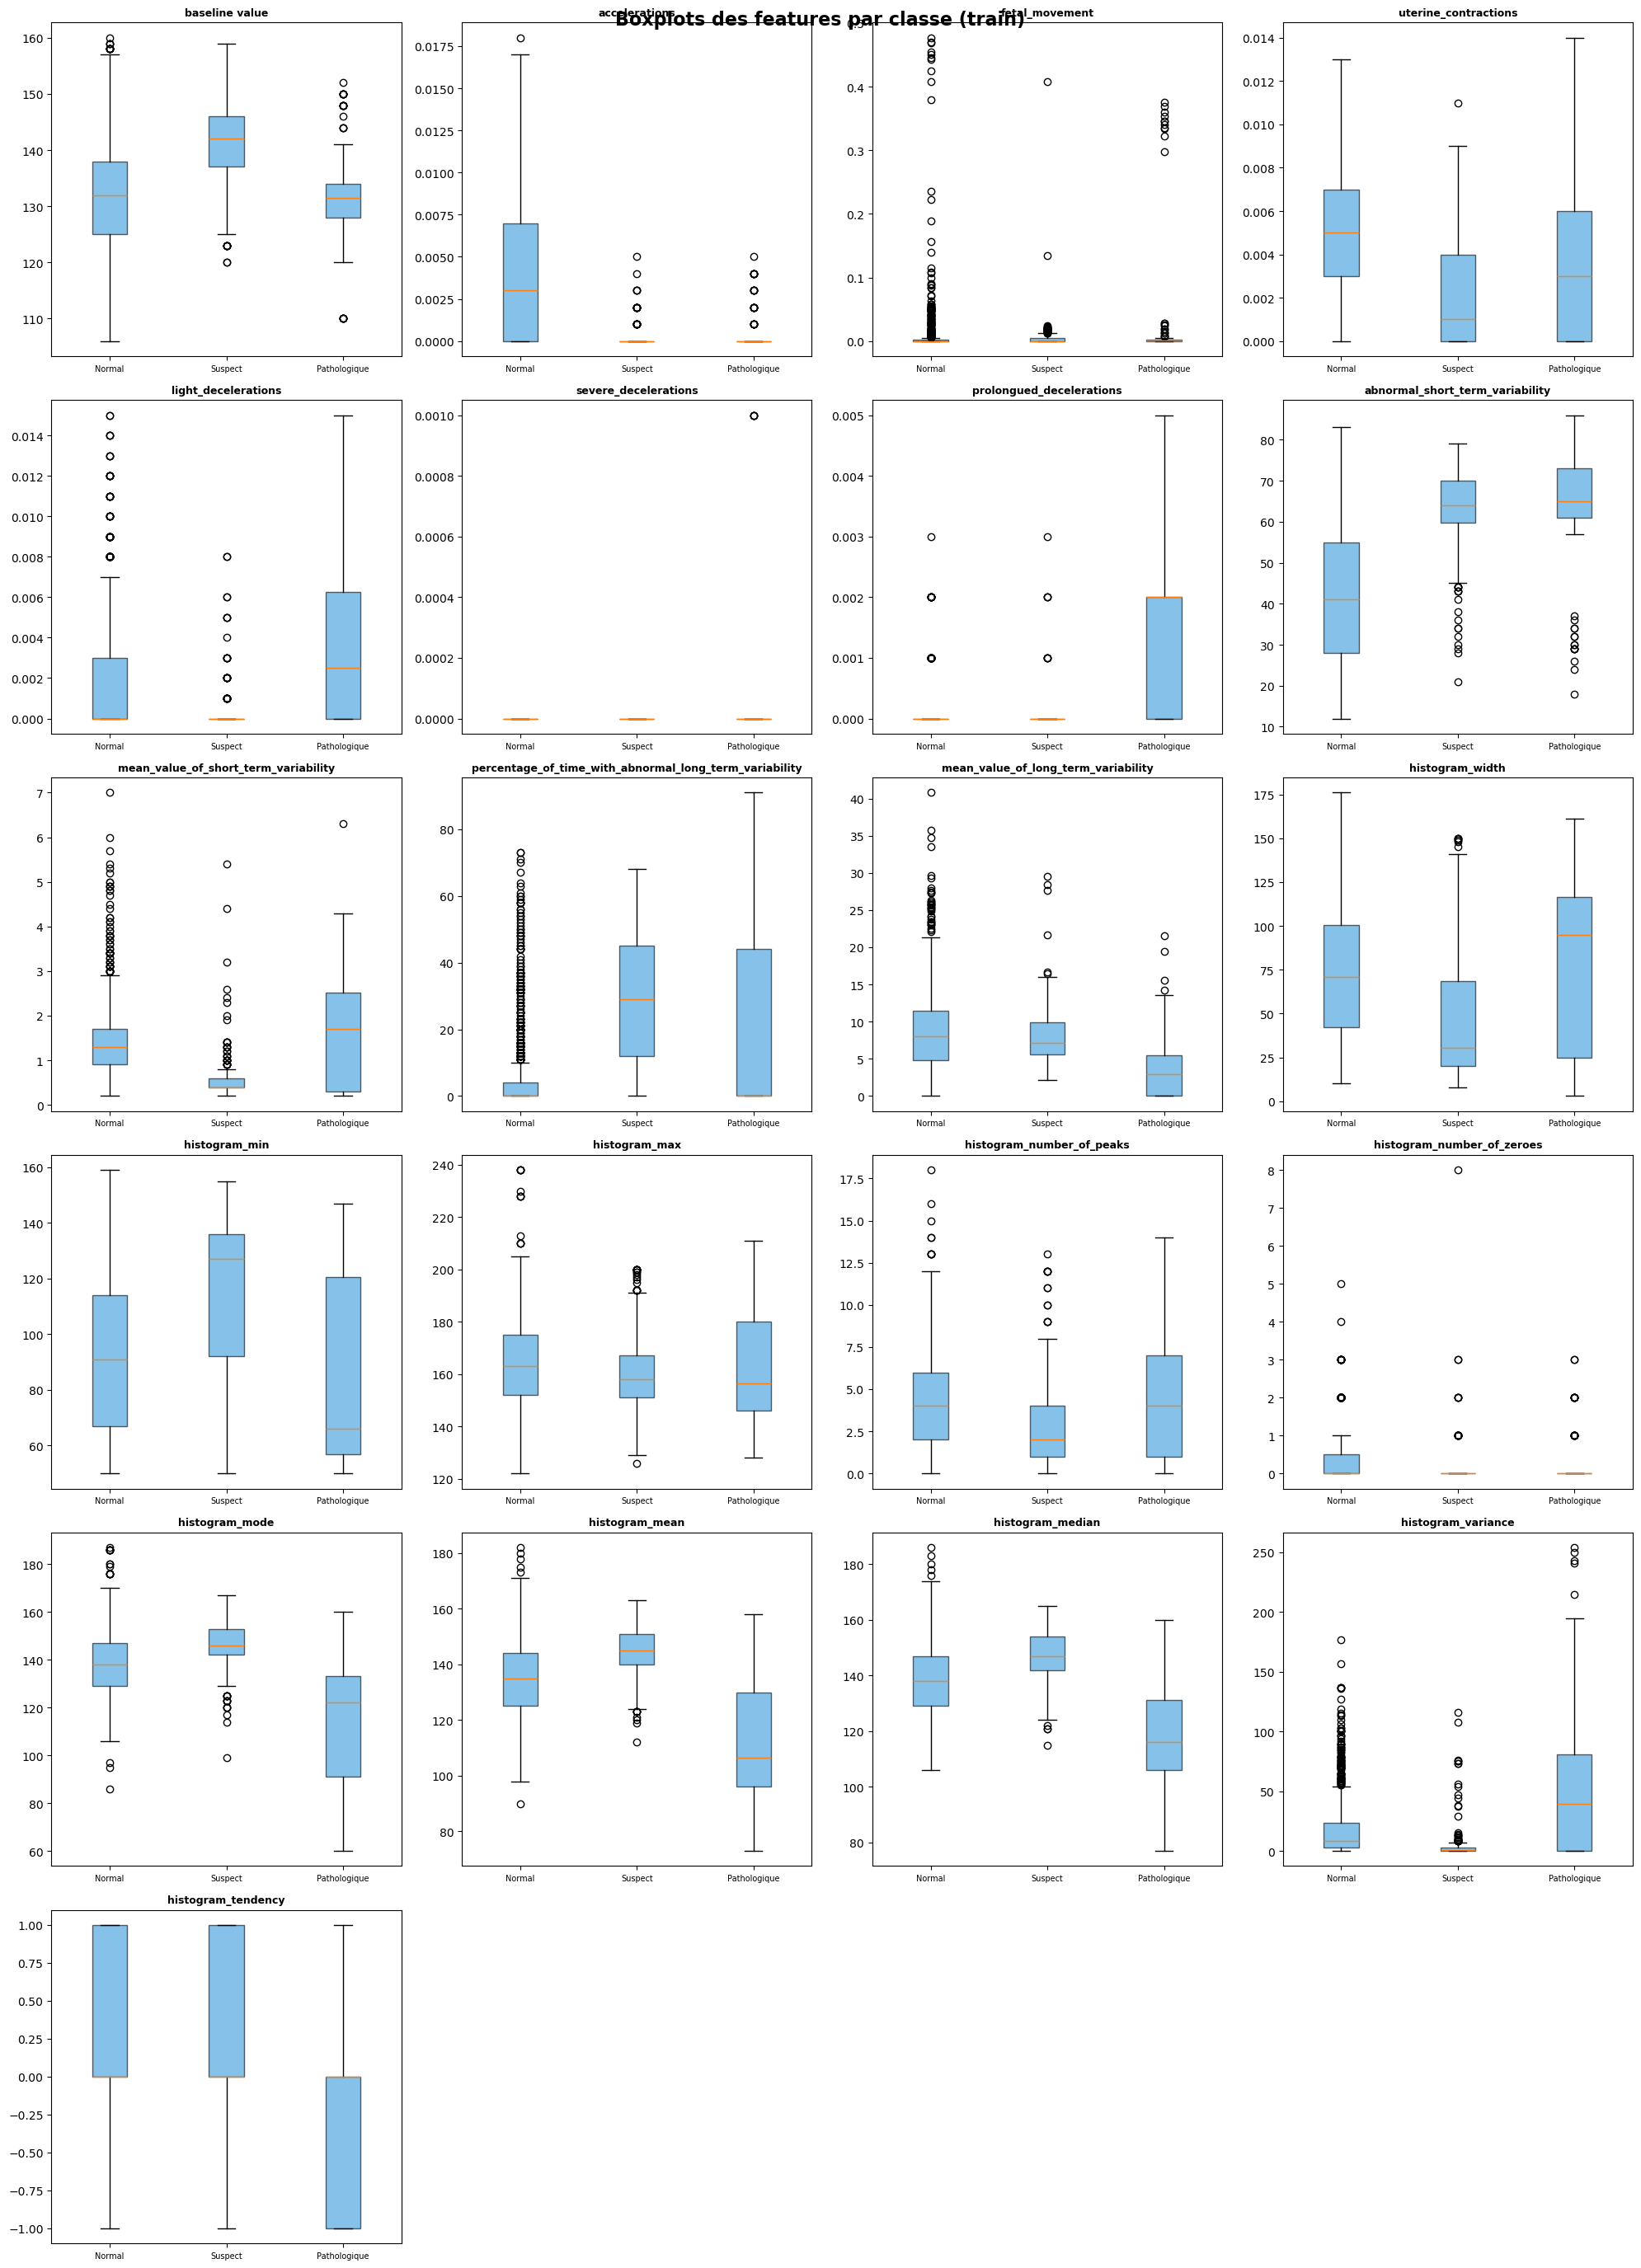

In [17]:
# Reconstruction du train set pour les boxplots
train_plot = X_train.copy()
train_plot['fetal_health'] = y_train

features_list = X_train.columns.tolist()

fig, axes = plt.subplots(6, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feature in enumerate(features_list):
    groups = [train_plot[train_plot['fetal_health'] == cls][feature].values 
              for cls in [1, 2, 3]]
    axes[i].boxplot(groups, labels=['Normal', 'Suspect', 'Pathologique'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[i].set_title(feature, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=7)

for j in range(len(features_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots des features par classe (train)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Features très discriminantes :**
- `accelerations` → quasi nul pour Suspect/Pathologique, élevé pour Normal
- `prolongued_decelerations` → nettement plus élevé pour Pathologique
- `abnormal_short_term_variability` → augmente clairement Normal → Pathologique
- `percentage_of_time_with_abnormal_long_term_variability` → même tendance
- `histogram_variance` → Normal faible, Pathologique élevé

 **Features moyennement discriminantes :**
- `baseline value`, `histogram_min`, `histogram_mode/mean/median`

 **Features peu discriminantes :**
- `fetal_movement`, `severe_decelerations` → quasi nul partout

### 3.3 Matrice de Corrélation
La heatmap révèle les corrélations entre features.

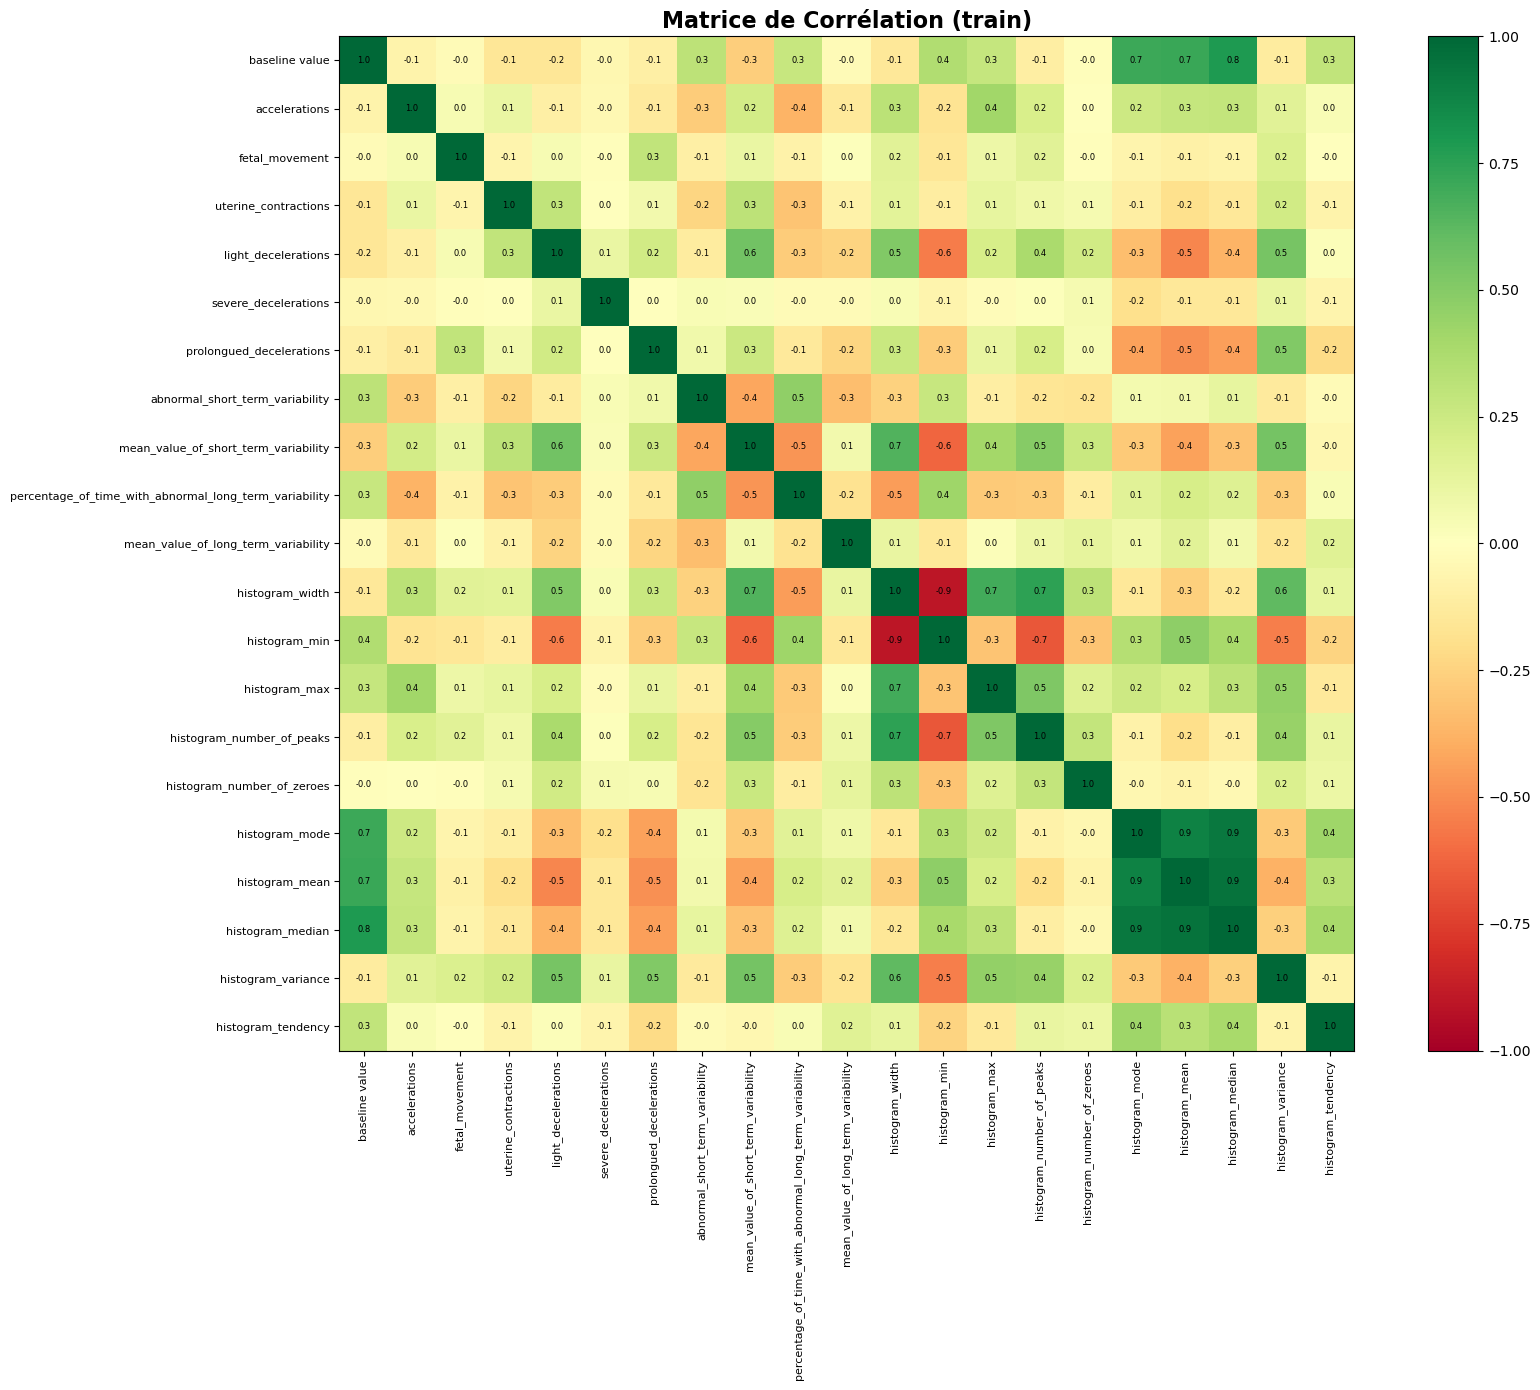

In [18]:
corr = X_train.corr()

plt.figure(figsize=(18, 14))
plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar()

labels_corr = corr.columns.tolist()
plt.xticks(range(len(labels_corr)), labels_corr, rotation=90, fontsize=8)
plt.yticks(range(len(labels_corr)), labels_corr, fontsize=8)

for i in range(len(labels_corr)):
    for j in range(len(labels_corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.1f}",
                 ha='center', va='center', fontsize=6)

plt.title("Matrice de Corrélation (train)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

 **Corrélations fortes détectées (>0.85) :**
- `histogram_mode` ↔ `histogram_mean` ↔ `histogram_median` : **0.9** → quasi identiques
- `histogram_width` ↔ `histogram_min` : **-0.9** → information redondante

**Action :** Supprimer `histogram_mode` et `histogram_median` (garder `histogram_mean`).
Ces suppressions seront faites après le Feature Engineering.

# SECTION 4 — FEATURE ENGINEERING
Basé sur l'EDA, on crée 3 nouvelles features qui capturent des relations cliniques importantes entre les mesures Cardiotocographie.

In [19]:
# Feature Engineering appliqué sur train et test séparément
for dataset in [X_train, X_test]:
    
    # Feature 1 : Ratio accélérations / décélérations totales
    decel_total = (dataset['light_decelerations'] + 
                   dataset['severe_decelerations'] + 
                   dataset['prolongued_decelerations'])
    dataset['accel_decel_ratio'] = dataset['accelerations'] / (decel_total + 1e-6)
    
    # Feature 2 : Score de variabilité globale
    dataset['variability_score'] = (dataset['abnormal_short_term_variability'] +
                                    dataset['percentage_of_time_with_abnormal_long_term_variability'])
    
    # Feature 3 : Amplitude de l'histogramme
    dataset['histogram_amplitude'] = dataset['histogram_mode'] - dataset['histogram_min']

print(f"Nouvelles features ajoutées : accel_decel_ratio, variability_score, histogram_amplitude")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Nouvelles features ajoutées : accel_decel_ratio, variability_score, histogram_amplitude
X_train shape: (1587, 24)
X_test shape: (532, 24)


**Justification clinique :**
 - `accel_decel_ratio` : rapport entre accélérations et décélérations → indicateur de bien-être fœtal
 - `variability_score` : combine les deux types de variabilité anormale → indicateur de stress
 - `histogram_amplitude` : écart entre le mode et le minimum de l'histogramme → forme de la distribution FHR

In [20]:
# Suppression des features redondantes identifiées dans la heatmap :
# - histogram_mode et histogram_median corrélées à >0.9 avec histogram_mean
# - accel_decel_ratio corrélée avec accelerations
# - histogram_max redondante

cols_to_drop = ['histogram_mode', 'histogram_median', 
                'accel_decel_ratio', 'histogram_max']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print(f"Features supprimées : {cols_to_drop}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Features supprimées : ['histogram_mode', 'histogram_median', 'accel_decel_ratio', 'histogram_max']
X_train shape: (1587, 20)
X_test shape: (532, 20)


# SECTION 5 — SÉLECTION DE FEATURES (ANOVA)
Le test ANOVA mesure si la moyenne d'une feature est **significativement différente** entre les 3 classes. Un F-score élevé et p-value < 0.05 indique une feature discriminante utile pour la classification.

In [21]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)
 
print(f"{'Feature':<55} {'F-score':>10} {'p-value':>10} {'Décision':>15}")
print("-" * 95)
for feature, score, pval in zip(X_train.columns, selector.scores_, selector.pvalues_):
    decision = "✅ Garder" if pval < 0.05 else "❌ Retirer"
    print(f"{feature:<55} {score:>10.2f} {pval:>10.4f} {decision:>15}")
 
all_columns = X_train.columns.tolist()
selected_features = [col for col, pval in zip(X_train.columns, selector.pvalues_) if pval < 0.05]
removed_features = [col for col, pval in zip(X_train.columns, selector.pvalues_) if pval >= 0.05]

X_train = X_train[selected_features]
X_test = X_test[selected_features]

print(f"\n Features retenues : {len(selected_features)}")
print(f" Features retirées : {removed_features}")
print(f"\nShape train final : {X_train.shape}")
print(f"Shape test final  : {X_test.shape}")

Feature                                                    F-score    p-value        Décision
-----------------------------------------------------------------------------------------------
baseline value                                               94.61     0.0000        ✅ Garder
accelerations                                               148.17     0.0000        ✅ Garder
fetal_movement                                               13.83     0.0000        ✅ Garder
uterine_contractions                                         76.40     0.0000        ✅ Garder
light_decelerations                                          52.23     0.0000        ✅ Garder
severe_decelerations                                         22.69     0.0000        ✅ Garder
prolongued_decelerations                                    460.64     0.0000        ✅ Garder
abnormal_short_term_variability                             278.48     0.0000        ✅ Garder
mean_value_of_short_term_variability                      

**Résultat :** Toutes les features restantes sont statistiquement significatives (p < 0.05).
`histogram_max`, `histogram_mode`, `histogram_median` et `accel_decel_ratio` avaient déjà
été retirées à l'étape précédente pour redondance.

# SECTION 6 — NORMALISATION
La normalisation est indispensable pour certains algorithmes sensibles à l'échelle des données (KNN, SVM). Le StandardScaler transforme chaque feature pour avoir **moyenne=0 et écart-type=1**.

In [22]:
from sklearn.preprocessing import StandardScaler

# Fit le scaler sur le train set, transformer les deux
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=selected_features,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=selected_features,
    index=X_test.index
)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (1587, 20)
X_test_scaled shape: (532, 20)


# SECTION 7 — ACP (Visualisation)
L'ACP est calculée sur le train set scalé pour visualiser
la structure des données d'entraînement.

In [23]:
import matplotlib.pyplot as plt
from fanalysis.pca import PCA

acp = PCA(std_unit=True, stats=True,
          row_labels=X_train_scaled.index,
          col_labels=selected_features)

acp.fit(X_train_scaled.values)

,std_unit,True
,n_components,None
,row_labels,"Index([ 883, ..., length=1587)"
,col_labels,"['baseline value', 'accelerations', ...]"
,stats,True


In [24]:
# 1. Eigenvalues
acp.eig_

array([[6.07025220e+00, 2.55248106e+00, 2.21454049e+00, 1.34897795e+00,
        1.22801634e+00, 9.93614793e-01, 9.81560406e-01, 8.56681555e-01,
        7.25432868e-01, 6.36473728e-01, 5.76690282e-01, 4.98284878e-01,
        3.93822181e-01, 3.37283580e-01, 2.81573167e-01, 1.71833636e-01,
        6.91515817e-02, 4.59461239e-02, 1.73831861e-02, 2.13460248e-31],
       [3.03512610e+01, 1.27624053e+01, 1.10727025e+01, 6.74488973e+00,
        6.14008168e+00, 4.96807397e+00, 4.90780203e+00, 4.28340777e+00,
        3.62716434e+00, 3.18236864e+00, 2.88345141e+00, 2.49142439e+00,
        1.96911091e+00, 1.68641790e+00, 1.40786583e+00, 8.59168180e-01,
        3.45757909e-01, 2.29730620e-01, 8.69159306e-02, 1.06730124e-30],
       [3.03512610e+01, 4.31136663e+01, 5.41863688e+01, 6.09312585e+01,
        6.70713402e+01, 7.20394141e+01, 7.69472162e+01, 8.12306239e+01,
        8.48577883e+01, 8.80401569e+01, 9.09236083e+01, 9.34150327e+01,
        9.53841436e+01, 9.70705615e+01, 9.84784274e+01, 9.9337

Les valeurs propres mesurent la **quantité de variance** capturée par chaque composante principale. Une valeur propre > 1 (critère de Kaiser) indique qu'une composante apporte plus d'information qu'une feature originale seule.

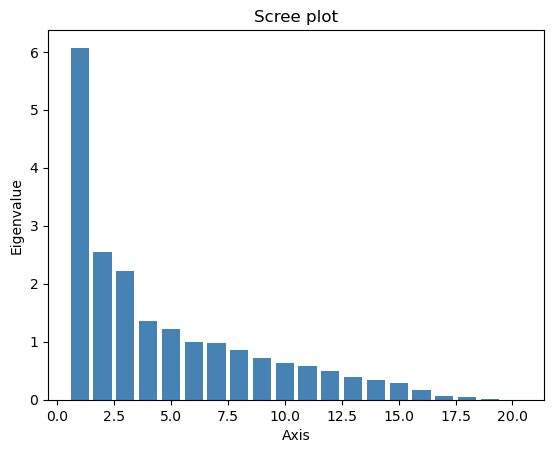

In [25]:
# 2. Scree Plot — valeurs propres
acp.plot_eigenvalues()

Le Scree Plot visualise les valeurs propres par composante.
On observe un **coude** vers la 3ème-4ème composante → les premières
composantes capturent l'essentiel de l'information du dataset.
Les composantes après le coude apportent peu d'information supplémentaire.

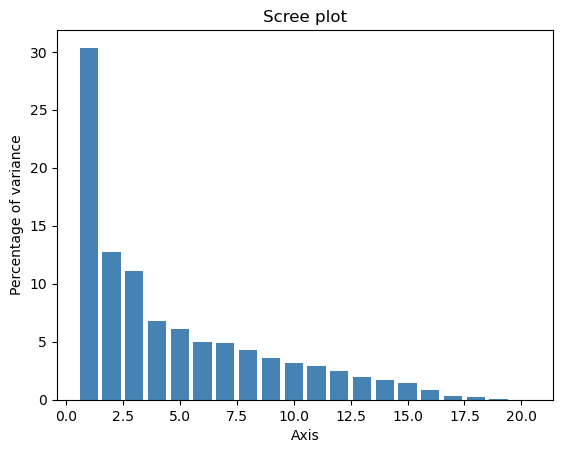

In [26]:
# 3. Variance expliquée en %
acp.plot_eigenvalues(type="percentage")

PC1 explique **30%** et PC2 **13%** → 43% au total pour 2 composantes.
Acceptable pour un dataset de 20 features corrélées entre elles.

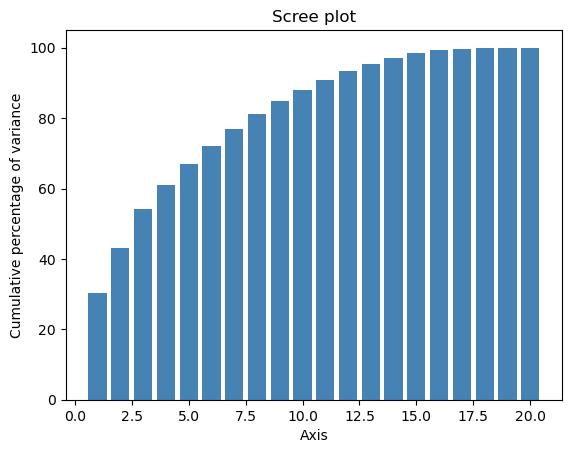

In [27]:
# 4. Variance cumulée
acp.plot_eigenvalues(type="cumulative")

Ce graphique montre combien de composantes sont nécessaires pour atteindre
un seuil de variance expliquée :
- **80%** de variance → environ 7 composantes
- **95%** de variance → environ 13 composantes

Cela confirme que les données CTG sont **multidimensionnelles** —
aucune réduction brutale n'est possible sans perte d'information significative.

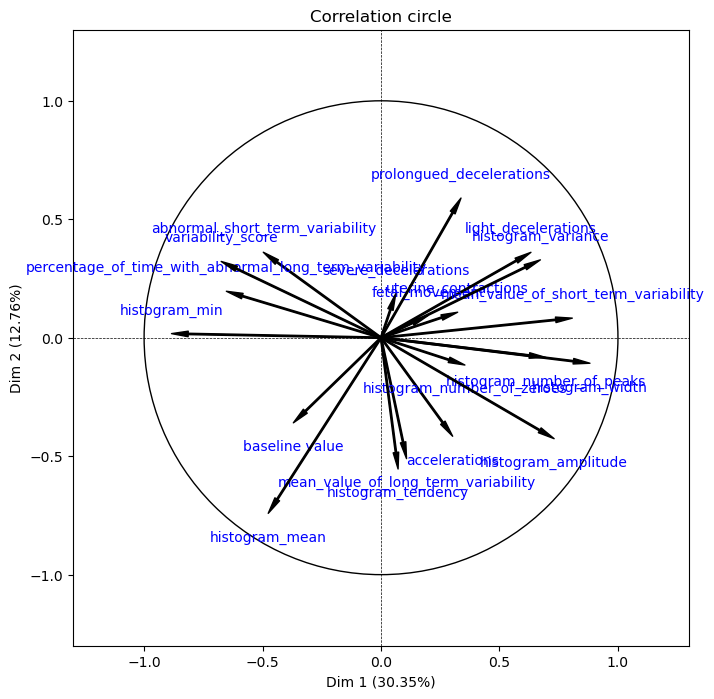

In [28]:
# 5. Cercle des corrélations
acp.correlation_circle(num_x_axis=1, num_y_axis=2, figsize=(10, 8))

Le cercle des corrélations montre la relation entre les features originales
et les composantes principales :

- **Axe gauche** : features de **détresse fœtale** (variabilité anormale, décélérations)
- **Axe droit** : features de **rythme cardiaque stable** (histogram_mean, baseline value)
- Flèches longues → bien représentées sur cet axe → features discriminantes

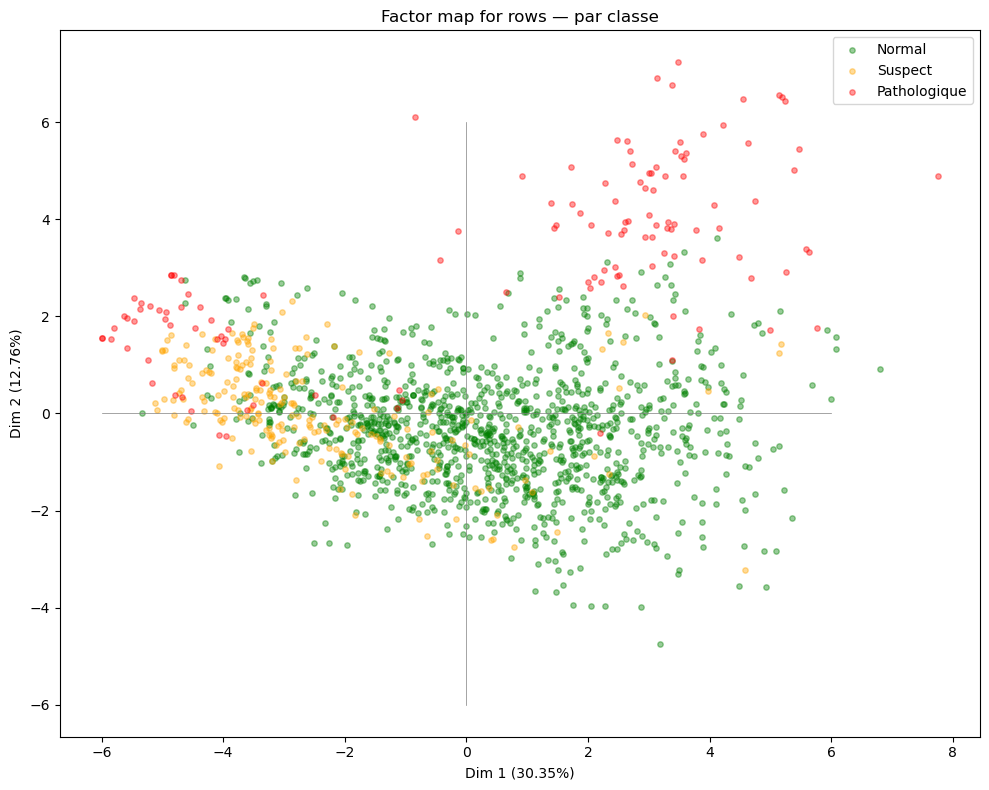

In [29]:
# 6. Mapping des individus coloré par classe
coords = acp.row_coord_
x_coord = coords[:, 0]
y_coord = coords[:, 1]

colors_map = {1: 'green', 2: 'orange', 3: 'red'}
labels_map = {1: 'Normal', 2: 'Suspect', 3: 'Pathologique'}

plt.figure(figsize=(10, 8))
axe = plt.gca()
axe.plot([-6, 6], [0, 0], color='gray', linewidth=0.5)
axe.plot([0, 0], [-6, 6], color='gray', linewidth=0.5)

for cls in [1, 2, 3]:
    mask = (y_train == cls)
    axe.scatter(x_coord[mask], y_coord[mask],
                c=colors_map[cls], label=labels_map[cls],
                alpha=0.4, s=15)

axe.set_xlabel(f"Dim 1 ({acp.eig_[1,0]:.2f}%)")
axe.set_ylabel(f"Dim 2 ({acp.eig_[1,1]:.2f}%)")
axe.set_title("Factor map for rows — par classe")
axe.legend()
plt.tight_layout()
plt.show()

Le plan factoriel projette chaque patient sur les 2 premières composantes :

- **Pathologique (rouge)** → concentré à gauche → fortement associé aux
  features de détresse (variabilité anormale, décélérations prolongées) ✅
- **Normal (vert)** → concentré à droite → rythme cardiaque stable ✅
- **Suspect (orange)** → chevauchement important avec Normal ⚠️ →
  confirme que cette classe est une **zone frontière** difficile à séparer

Cette séparation visuelle explique pourquoi tous nos modèles détectent
bien Normal et Pathologique, mais peinent sur Suspect.

# SECTION 8 — SMOTE
### 8.1 SMOTE — Rééquilibrage des classes
SMOTE génère des exemples synthétiques des classes minoritaires **uniquement sur le train set**.
L'appliquer sur le test set créerait un **data leakage** — le modèle serait évalué sur des données artificielles.

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
 
print(f"Avant SMOTE : {pd.Series(y_train).value_counts().sort_index().to_dict()}")
print(f"Après SMOTE : {pd.Series(y_train_res).value_counts().sort_index().to_dict()}")
print(f"\nTrain après SMOTE : {X_train_res.shape}")

Avant SMOTE : {1: 1235, 2: 220, 3: 132}
Après SMOTE : {1: 1235, 2: 1235, 3: 1235}

Train après SMOTE : (3705, 20)


**Résultat :** 3 classes équilibrées à 1235 exemples chacune.
Le train passe de 1587 à 3705 lignes.

In [31]:
# Préparation des variables pour la modélisation
X_test = X_test_scaled
print(f"X_train_res (train après SMOTE): {X_train_res.shape}")
print(f"X_test (test scalé): {X_test.shape}")

X_train_res (train après SMOTE): (3705, 20)
X_test (test scalé): (532, 20)


# SECTION 9 — MODÉLISATION PARTIE A : MODÈLES DE BASE
 On commence par 3 algorithmes de base pour établir une baseline.
Pour chaque modèle : **tuning GridSearchCV (cv=10)** puis **entraînement**.

### 9.1 KNN — K-Nearest Neighbors

KNN classe un point selon les k voisins les plus proches.
Il est sensible à l'échelle → la normalisation est essentielle.
On cherche le meilleur k, la métrique de distance et la pondération.

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
 
params = {
    'n_neighbors': range(1, 16),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
 
grid = GridSearchCV(KNeighborsClassifier(),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Meilleure accuracy CV : 0.9806


In [33]:
knn = KNeighborsClassifier(n_neighbors=1, weights='uniform', metric='manhattan')
knn.fit(X_train_res, y_train_res)
y_pred_knn = knn.predict(X_test)
 
print(classification_report(y_test, y_pred_knn,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96       414
     Suspect       0.74      0.72      0.73        74
Pathologique       0.86      0.82      0.84        44

    accuracy                           0.92       532
   macro avg       0.85      0.83      0.84       532
weighted avg       0.91      0.92      0.91       532



**Interprétation KNN :**
- Accuracy : **92%** — bonne baseline pour un modèle de base
- Normal (F1=0.96) : excellente détection ✅
- Pathologique (F1=0.84) : bonne détection ✅ — cliniquement important
- Suspect (F1=0.73) : classe frontière difficile ⚠️

**Interprétation médicale KNN :**

Accuracy globale de 92%. Le modèle détecte correctement 96% des cas normaux,
évitant ainsi des hospitalisations inutiles. Pour les cas pathologiques,
le recall de 82% signifie que **18% des fœtus en détresse passent inaperçus**
— ce qui est cliniquement inacceptable si utilisé seul. La classe Suspect
est la plus difficile (F1=0.73) car ses signes vitaux chevauchent ceux des
cas normaux et pathologiques.

### 9.2 SVM — Support Vector Machine
Le SVM cherche l'hyperplan qui maximise la marge entre les classes.
 Avec kernel RBF, il gère bien les données non-linéaires.
 Le paramètre C contrôle le compromis biais/variance.

In [34]:
from sklearn.svm import SVC
 
params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
 
grid = GridSearchCV(SVC(random_state=42),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Meilleure accuracy CV : 0.9792


In [35]:
svm = SVC(C=100, gamma='auto', kernel='rbf', random_state=42)
svm.fit(X_train_res, y_train_res)
y_pred_svm = svm.predict(X_test)
 
print(classification_report(y_test, y_pred_svm,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.94      0.97      0.96       414
     Suspect       0.73      0.61      0.66        74
Pathologique       0.82      0.84      0.83        44

    accuracy                           0.91       532
   macro avg       0.83      0.81      0.82       532
weighted avg       0.90      0.91      0.90       532



**Interprétation SVM :**
- Accuracy : **91%** — légèrement inférieur au KNN
- Pathologique (F1=0.83) : correct mais moins bon que KNN
- Suspect (F1=0.66) : le plus faible des modèles de base ⚠️
- C=100 → le modèle préfère une frontière précise au risque d'overfitter légèrement

**Interprétation médicale SVM :**

Le SVM atteint 91% d'accuracy mais son recall pour Suspect tombe à 61% →
**39% des fœtus suspects ne sont pas identifiés**, ce qui retarde leur
surveillance médicale. En obstétrique, un cas suspect non détecté peut
évoluer vers un état pathologique sans intervention. Le modèle est trop
conservateur sur cette classe intermédiaire.

### 9.3 Decision Tree
L'arbre de décision crée des règles de décision binaires.
 Avantage : interprétable cliniquement.
 max_depth limite la profondeur pour éviter l'overfitting.

In [36]:
from sklearn.tree import DecisionTreeClassifier
 
params = {
    'max_depth': range(1, 15),
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
 
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'criterion': 'entropy', 'max_depth': 13, 'min_samples_split': 2}
Meilleure accuracy CV : 0.9646


In [37]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=13,
                             min_samples_split=2, random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)
 
print(classification_report(y_test, y_pred_dt,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       414
     Suspect       0.69      0.69      0.69        74
Pathologique       0.87      0.89      0.88        44

    accuracy                           0.90       532
   macro avg       0.83      0.84      0.84       532
weighted avg       0.90      0.90      0.90       532



**Interprétation Decision Tree :**
- Accuracy : **90%** — le moins bon des modèles de base
- Pathologique (F1=0.88) : meilleur que SVM ✅
- Suspect (F1=0.69) : difficile mais équilibré (precision ≈ recall)

**Interprétation médicale Decision Tree :**

Le Decision Tree obtient 90% d'accuracy avec un recall de 89% pour
Pathologique → seuls **11% des fœtus en détresse sont manqués**.
Son avantage majeur est son **interprétabilité** : le médecin peut
visualiser les règles de décision (ex: si prolongued_decelerations > X
et variability_score > Y → Pathologique) et les valider cliniquement.
C'est le modèle le plus transparent médicalement.

 ### Bilan Partie A — Modèles de Base


| Modèle | Accuracy | F1 Suspect | F1 Pathologique |
|--------|----------|------------|-----------------|
| KNN    | **0.92** | **0.73**   | **0.84**        |
| SVM    | 0.91     | 0.66       | 0.83            |
| DT     | 0.90     | 0.69       | 0.88            |

 Tous les modèles de base atteignent **~91-92%** — bonne baseline.
 La classe Suspect reste la plus difficile pour tous les modèles.

# SECTION 10 — MODÉLISATION PARTIE B : MÉTHODES D'ENSEMBLE
Les méthodes d'ensemble combinent plusieurs modèles pour réduire
la variance et améliorer la généralisation. On teste 4 algorithmes.

### 10.1 Random Forest
 Random Forest entraîne plusieurs arbres de décision sur des
 sous-ensembles aléatoires des données et des features (bagging).
 Plus robuste qu'un seul arbre, il réduit l'overfitting.

In [38]:
from sklearn.ensemble import RandomForestClassifier
 
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [6, 8, 12, None],
    'min_samples_split': [2, 5, 10]
}
 
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Meilleure accuracy CV : 0.9806


In [39]:
rf = RandomForestClassifier(max_depth=None, min_samples_split=2,
                             n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
 
print(classification_report(y_test, y_pred_rf,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       414
     Suspect       0.80      0.76      0.78        74
Pathologique       0.89      0.93      0.91        44

    accuracy                           0.93       532
   macro avg       0.88      0.88      0.88       532
weighted avg       0.93      0.93      0.93       532



**Interprétation Random Forest (200 arbres, max_depth=None) :**
- Accuracy : **93%** → meilleur que tous les modèles de base ✅
- Suspect (F1=0.78) : nette amélioration ✅
- Pathologique (F1=0.91) : excellente détection ✅
- max_depth=None → les arbres peuvent grandir librement pour capturer les patterns CTG complexes

**Interprétation médicale Random Forest :**

Avec 93% d'accuracy et un recall de 93% pour Pathologique, le Random Forest
manque seulement **7% des cas de détresse fœtale**. Cette performance est
cliniquement significative : sur 44 cas pathologiques du test set, 41 sont
correctement identifiés. Le F1 Suspect de 0.78 représente aussi une nette
amélioration — la surveillance médicale est mieux ciblée.

### 10.2 AdaBoost
AdaBoost entraîne des modèles séquentiellement, chaque nouveau modèle
 se concentrant sur les erreurs du précédent (boosting).
 Plus sensible au bruit que Random Forest.

In [40]:
from sklearn.ensemble import AdaBoostClassifier
 
params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
 
grid = GridSearchCV(AdaBoostClassifier(random_state=42),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'learning_rate': 1.0, 'n_estimators': 100}
Meilleure accuracy CV : 0.9236


In [41]:
ada = AdaBoostClassifier(learning_rate=1.0, n_estimators=100, random_state=42)
ada.fit(X_train_res, y_train_res)
y_pred_ada = ada.predict(X_test)
 
print(classification_report(y_test, y_pred_ada,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.95      0.86      0.90       414
     Suspect       0.49      0.80      0.61        74
Pathologique       0.88      0.82      0.85        44

    accuracy                           0.84       532
   macro avg       0.77      0.82      0.79       532
weighted avg       0.88      0.84      0.86       532



**Interprétation AdaBoost (lr=1.0, n=100) :**
- Accuracy : **84%** → le moins performant de tous les modèles ❌
- Suspect (F1=0.61) : très faible precision (0.49) → beaucoup de faux positifs
- Pathologique (F1=0.85) : correct
- AdaBoost est plus sensible au déséquilibre des classes malgré le SMOTE

**Interprétation médicale AdaBoost :**

L'AdaBoost montre des résultats préoccupants avec seulement 84% d'accuracy.
Bien que son recall Suspect soit correct (80%), sa **précision Suspect de 49%**
signifie que plus de la moitié des cas classés "Suspect" sont en réalité
normaux → surcharge inutile du personnel médical. En milieu hospitalier,
cela génèrerait trop de fausses alarmes et une perte de confiance dans le
système. Ce modèle **n'est pas recommandé en contexte clinique**.

### 10.3 XGBoost
XGBoost est un algorithme de gradient boosting optimisé.
 Il combine plusieurs arbres séquentiellement avec régularisation
 pour éviter l'overfitting. Très performant sur données tabulaires.

⚠️ XGBoost nécessite des classes encodées à partir de 0  on soustrait 1.

In [42]:
from xgboost import XGBClassifier
 
y_train_res_xgb = y_train_res - 1
y_test_xgb = y_test - 1
 
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}
 
grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res_xgb)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Meilleure accuracy CV : 0.9835


In [43]:
xgb = XGBClassifier(learning_rate=0.3, max_depth=4, n_estimators=200,
                    subsample=0.8, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_res, y_train_res_xgb)
y_pred_xgb = xgb.predict(X_test)
 
print(classification_report(y_test_xgb, y_pred_xgb,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       414
     Suspect       0.83      0.74      0.79        74
Pathologique       0.89      0.91      0.90        44

    accuracy                           0.94       532
   macro avg       0.89      0.88      0.88       532
weighted avg       0.94      0.94      0.94       532



**Interprétation XGBoost (lr=0.3, max_depth=4, n=200) :**
- Accuracy : **94%** → excellent résultat ✅
- Normal (F1=0.97) : quasi parfait ✅
- Suspect (F1=0.79) : meilleur résultat sur cette classe difficile ✅
- Pathologique (F1=0.90) : très bonne détection ✅

**Interprétation médicale XGBoost :**

XGBoost atteint 94% d'accuracy avec un recall de 91% pour Pathologique
→ **9% des fœtus en détresse non détectés**. Sa précision de 89% pour
Pathologique garantit que les alertes générées sont fiables, évitant
les faux positifs qui entraîneraient des césariennes inutiles.
Le F1 Suspect de 0.79 est le meilleur parmi tous les modèles testés,
ce qui permet une meilleure orientation vers la surveillance préventive.

### 10.4 LightGBM
LightGBM est une version plus rapide du gradient boosting.
 Il utilise une croissance d'arbre par feuille (leaf-wise) plutôt
 que par niveau, ce qui le rend plus précis sur les données complexes.

In [44]:
from lightgbm import LGBMClassifier
 
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.1, 0.3],
    'num_leaves': [15, 31, 50]
}
 
grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1),
                    params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_res, y_train_res)
 
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleure accuracy CV : {grid.best_score_:.4f}")

Meilleurs paramètres : {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 50}
Meilleure accuracy CV : 0.9862


In [45]:
lgbm = LGBMClassifier(learning_rate=0.3, max_depth=6, n_estimators=200,
                      num_leaves=50, random_state=42, verbose=-1)
lgbm.fit(X_train_res, y_train_res)
y_pred_lgbm = lgbm.predict(X_test)
 
print(classification_report(y_test, y_pred_lgbm,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       414
     Suspect       0.82      0.76      0.79        74
Pathologique       0.89      0.91      0.90        44

    accuracy                           0.94       532
   macro avg       0.89      0.88      0.89       532
weighted avg       0.94      0.94      0.94       532



**Interprétation LightGBM (lr=0.3, max_depth=6, num_leaves=50) :**
- Accuracy : **94%** → égale XGBoost ✅
- Normal (F1=0.97) : quasi parfait ✅
- Suspect (F1=0.79) : même niveau que XGBoost
- Pathologique (F1=0.90) : excellente détection ✅

**Interprétation médicale LightGBM :**

LightGBM égale XGBoost avec 94% d'accuracy. Son recall de 91% pour
Pathologique et sa précision de 89% offrent un bon équilibre entre
**sensibilité** (détecter les vrais cas graves) et **spécificité**
(éviter les fausses alarmes). En obstétrique, ce compromis est crucial :
trop de faux positifs génèrent des interventions inutiles, trop de faux
négatifs mettent des vies en danger. LightGBM est également plus rapide
que XGBoost, ce qui le rend adapté à une utilisation en temps réel
pendant le travail.

### Bilan Partie B — Méthodes d'Ensemble

| Modèle        | Accuracy | F1 Suspect | F1 Pathologique |
|---------------|----------|------------|-----------------|
| Random Forest | 0.93     | 0.78       | 0.91            |
| AdaBoost      | 0.84     | 0.61       | 0.85            |
| XGBoost       | **0.94** | **0.79**   | 0.90            |
| LightGBM      | **0.94** | **0.79**   | 0.90            |

 XGBoost et LightGBM domine 

# SECTION 11 — COMBINAISON DES MODÈLES
On combine les meilleurs modèles pour tenter de dépasser les performances individuelles.

 ⚠️ XGBoost est exclu car ses classes sont encodées différemment (0/1/2 vs 1/2/3).

### 11.1 Voting Hard
 Chaque modèle vote pour une classe. La classe majoritaire est choisie.
 Simple mais efficace quand les modèles font des erreurs différentes.

In [46]:
from sklearn.ensemble import VotingClassifier
 
voting_hard = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(max_depth=None, min_samples_split=2,
                                       n_estimators=200, random_state=42)),
        ('lgbm', LGBMClassifier(learning_rate=0.3, max_depth=6, n_estimators=200,
                                 num_leaves=50, random_state=42, verbose=-1)),
        ('ada', AdaBoostClassifier(learning_rate=1.0, n_estimators=100, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=1, weights='uniform', metric='manhattan'))
    ],
    voting='hard'
)
 
voting_hard.fit(X_train_res, y_train_res)
y_pred_vh = voting_hard.predict(X_test)
 
print(classification_report(y_test, y_pred_vh,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       414
     Suspect       0.85      0.74      0.79        74
Pathologique       0.90      0.86      0.88        44

    accuracy                           0.94       532
   macro avg       0.90      0.86      0.88       532
weighted avg       0.94      0.94      0.94       532



**Interprétation Voting Hard :**
- Accuracy : **94%** → maintient le niveau des meilleurs modèles individuels
- Suspect (F1=0.79) : bon résultat
- Pathologique (F1=0.88) : légèrement en dessous de RF seul
- La combinaison par vote majoritaire n'améliore pas significativement les résultats ici

**Interprétation médicale Voting Hard :**

Le Voting Hard combine 4 modèles par vote majoritaire. Avec 94% d'accuracy
et un recall de 86% pour Pathologique, il est légèrement moins sensible
que LightGBM seul sur les cas graves. L'avantage du Voting est sa
**robustesse** : même si un modèle fait une erreur sur un cas particulier,
les 3 autres peuvent corriger. En pratique médicale, un système redondant
qui confirme le diagnostic de plusieurs sources est souvent préféré.

### 11.2 Voting Soft
 Chaque modèle donne des probabilités pour chaque classe.
 La classe avec la probabilité moyenne la plus élevée est choisie.
 Plus nuancé que le vote hard — prend en compte la confiance des modèles.

In [47]:
voting_soft = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(max_depth=None, min_samples_split=2,
                                       n_estimators=200, random_state=42)),
        ('lgbm', LGBMClassifier(learning_rate=0.3, max_depth=6, n_estimators=200,
                                 num_leaves=50, random_state=42, verbose=-1)),
        ('ada', AdaBoostClassifier(learning_rate=1.0, n_estimators=100, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=1, weights='uniform', metric='manhattan'))
    ],
    voting='soft'
)
 
voting_soft.fit(X_train_res, y_train_res)
y_pred_vs = voting_soft.predict(X_test)
 
print(classification_report(y_test, y_pred_vs,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       414
     Suspect       0.81      0.77      0.79        74
Pathologique       0.89      0.89      0.89        44

    accuracy                           0.94       532
   macro avg       0.89      0.88      0.88       532
weighted avg       0.94      0.94      0.94       532



**Interprétation Voting Soft :**
- Accuracy : **94%** → identique au Hard
- Suspect (F1=0.79) : même niveau
- La moyenne des probabilités donne des résultats similaires au vote majoritaire

**Interprétation médicale Voting Soft :**

Le Voting Soft avec 94% d'accuracy et recall Pathologique de 89% offre
un meilleur résultat que le Hard sur les cas graves. La moyenne des
probabilités est plus nuancée : au lieu de "oui ou non", le modèle
donne un **score de confiance** pour chaque classe. En médecine, ce
score peut être affiché au clinicien (ex: "85% de probabilité de
Pathologique") pour l'aider à prendre une décision informée plutôt
qu'une décision binaire.

### 11.3 Stacking
 Le Stacking entraîne un méta-modèle (LogisticRegression) qui apprend
 à combiner les prédictions des modèles de base.
 Plus sophistiqué que le Voting — le méta-modèle apprend les forces
 et faiblesses de chaque modèle.

In [48]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
 
stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(max_depth=None, min_samples_split=2,
                                       n_estimators=200, random_state=42)),
        ('lgbm', LGBMClassifier(learning_rate=0.3, max_depth=6, n_estimators=200,
                                 num_leaves=50, random_state=42, verbose=-1)),
        ('ada', AdaBoostClassifier(learning_rate=1.0, n_estimators=100, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=1, weights='uniform', metric='manhattan'))
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=10
)
 
stacking.fit(X_train_res, y_train_res)
y_pred_stack = stacking.predict(X_test)
 
print(classification_report(y_test, y_pred_stack,
      target_names=['Normal', 'Suspect', 'Pathologique']))

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       414
     Suspect       0.83      0.74      0.79        74
Pathologique       0.87      0.89      0.88        44

    accuracy                           0.94       532
   macro avg       0.89      0.87      0.88       532
weighted avg       0.93      0.94      0.93       532



**Interprétation Stacking :**
- Accuracy : **94%** → même niveau que les autres ensembles
- Suspect (F1=0.79) : cohérent avec les autres méthodes de combinaison
- La LogisticRegression comme méta-modèle apprend à pondérer les modèles de base

**Interprétation médicale Stacking :**

Le Stacking avec méta-modèle LogisticRegression atteint 94% d'accuracy
et recall de 89% pour Pathologique. Il apprend à exploiter les **forces
complémentaires** de chaque modèle : KNN performant sur les patterns
locaux, LightGBM sur les patterns globaux, RF sur la robustesse.
Cliniquement, c'est l'équivalent d'un **avis collégial médical** :
plusieurs experts se prononcent et un coordinateur synthétise leur
opinion pour une décision finale.

### Bilan Partie C — Combinaison des Modèles
| Méthode      | Accuracy | F1 Suspect | F1 Pathologique |
|--------------|----------|------------|-----------------|
| Voting Hard  | 0.94     | 0.79       | 0.88            |
| Voting Soft  | 0.94     | 0.79       | 0.89            |
| Stacking     | 0.94     | 0.79       | 0.88            |

# SECTION 12 — ÉVALUATION FINALE : CROSS-VALIDATION 10-FOLD
La validation croisée 10-fold est plus fiable qu'un simple test set car :
 - Elle évalue le modèle sur **10 partitions différentes** des données
 - Elle mesure la **stabilité** (std) en plus de la performance moyenne
 - Elle réduit le risque d'overfitting sur un test set particulier

On utilise un **Pipeline** (StandardScaler + Modèle) avec les données
**avant normalisation** (`X_train`). Le StandardScaler est recalculé
à l'intérieur de chaque fold — aucune information ne fuite entre folds.

In [49]:
from sklearn.model_selection import cross_val_score

# Les données X_test sont déjà normalisées → pas besoin de Pipeline
# On évalue sur le test set avec CV stratifiée
modeles = {
    'KNN'          : knn,
    'SVM'          : svm,
    'Decision Tree': dt,
    'Random Forest': rf,
    'AdaBoost'     : ada,
    'LightGBM'     : lgbm,
    'Voting Hard'  : voting_hard,
    'Voting Soft'  : voting_soft,
    'Stacking'     : stacking
}

print(f"{'Modèle':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 55)

for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_test, y_test, cv=10, scoring='accuracy')
    print(f"{nom:<20} {scores.mean():.4f}   {scores.std():.4f}   {scores.min():.4f}   {scores.max():.4f}")

Modèle                   Mean      Std      Min      Max
-------------------------------------------------------
KNN                  0.8721   0.0292   0.8302   0.9259
SVM                  0.8797   0.0329   0.8302   0.9245
Decision Tree        0.8853   0.0524   0.7925   0.9434
Random Forest        0.8947   0.0284   0.8491   0.9444
AdaBoost             0.8666   0.0292   0.8148   0.9057
LightGBM             0.9173   0.0256   0.8679   0.9623
Voting Hard          0.8947   0.0282   0.8491   0.9444
Voting Soft          0.9041   0.0298   0.8679   0.9444
Stacking             0.9173   0.0339   0.8679   0.9811


**Analyse des résultats :**
- **LightGBM et Stacking** → meilleurs en CV (0.917) avec bonne stabilité ✅
- **Voting Soft** → bon équilibre performance/stabilité (0.904)
- **AdaBoost** → le moins performant (0.867) et instable ⚠️
- **KNN** → std faible (0.029) mais moyenne modeste (0.872)

La différence entre test set (~94%) et CV (~91%) s'explique par le SMOTE :
le train set équilibré est plus facile à apprendre, mais la CV évalue
sur des données réelles déséquilibrées.

# SECTION 13 — XAI — Explicabilité des Modèles

In [50]:
#Initialisation SHAP + LIME
import shap
import lime
import lime.lime_tabular
 
# SHAP
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)
 
# shap_values shape : (n_samples, n_features, n_classes)
shap_normal  = shap_values[:, :, 0]   # Classe Normal
shap_suspect = shap_values[:, :, 1]   # Classe Suspect
shap_patho   = shap_values[:, :, 2]   # Classe Pathologique
 
# LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_res.values,
    feature_names  = selected_features,
    class_names    = ['Normal', 'Suspect', 'Pathologique'],
    mode           = 'classification',
    random_state   = 42
)
 
# Index des cas représentatifs 
idx_normal  = X_test[y_test.values == 1].index[0]
idx_suspect = X_test[y_test.values == 2].index[0]
idx_patho   = X_test[y_test.values == 3].index[0]
 
pos_n = X_test.index.get_loc(idx_normal)
pos_s = X_test.index.get_loc(idx_suspect)
pos_p = X_test.index.get_loc(idx_patho)
 
print(" SHAP et LIME initialisés")
print(f"  Cas Normal       → index {pos_n}")
print(f"  Cas Suspect      → index {pos_s}")
print(f"  Cas Pathologique → index {pos_p}")

 SHAP et LIME initialisés
  Cas Normal       → index 0
  Cas Suspect      → index 7
  Cas Pathologique → index 13


### 13.1 Vue Globale — Importance des Features

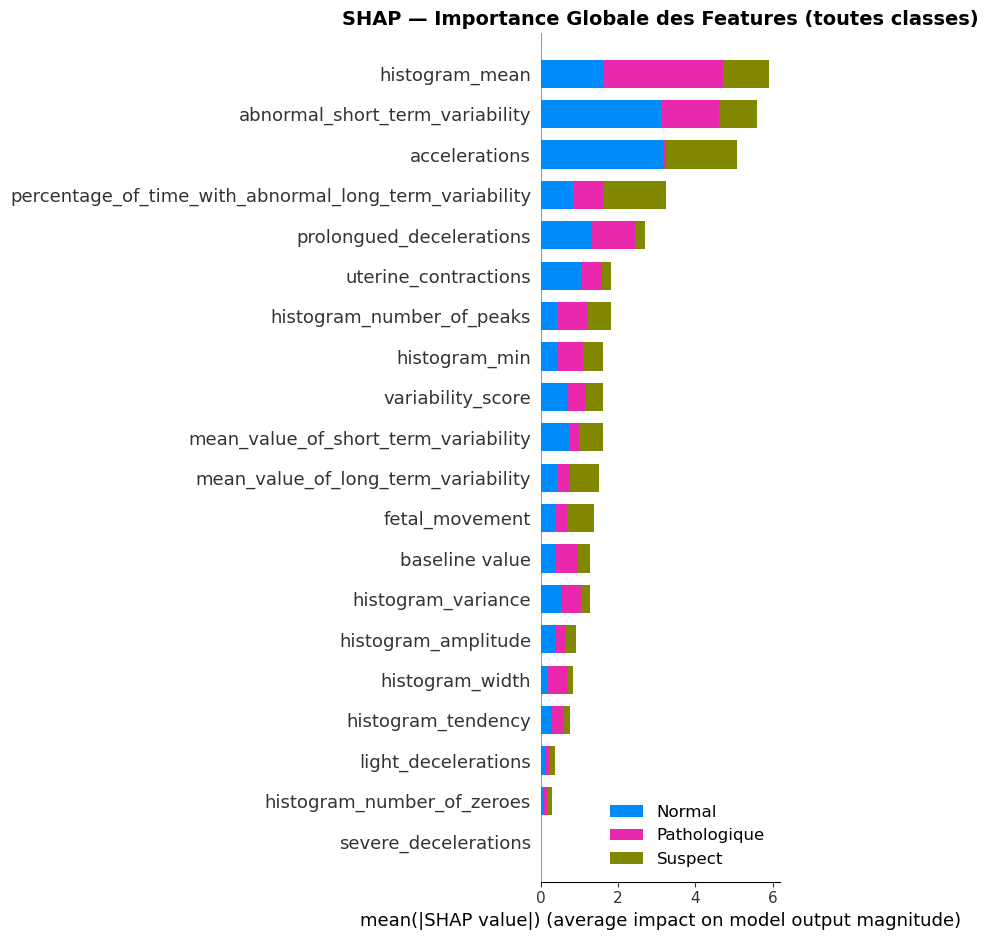

In [51]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    [shap_normal, shap_suspect, shap_patho],
    X_test.values,
    class_names    = ['Normal', 'Suspect', 'Pathologique'],
    plot_type      = 'bar',
    feature_names  = selected_features,
    show           = False
)
plt.title("SHAP — Importance Globale des Features (toutes classes)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Le graphique montre l'impact moyen absolu de chaque feature sur les prédictions du modèle pour les 3 classes. Plus la barre est longue, plus la feature est importante.

 **Observations :**
 - `histogram_mean` et `abnormal_short_term_variability` → features les plus
   influentes pour distinguer les 3 classes
 - `accelerations` → très important pour identifier les cas Normaux
 - `prolongued_decelerations` → feature clé pour détecter les Pathologiques
 - `severe_decelerations` → faible impact global

 **Interprétation médicale :** Le modèle s'appuie sur les indicateurs CTG
 cliniquement reconnus — la variabilité du rythme et les décélérations
 prolongées sont les marqueurs principaux de détresse fœtale.

### 13.2 Classe Normal — Analyse Détaillée
Analyse des features qui conduisent le modèle à prédire qu'un fœtus est en bonne santé.

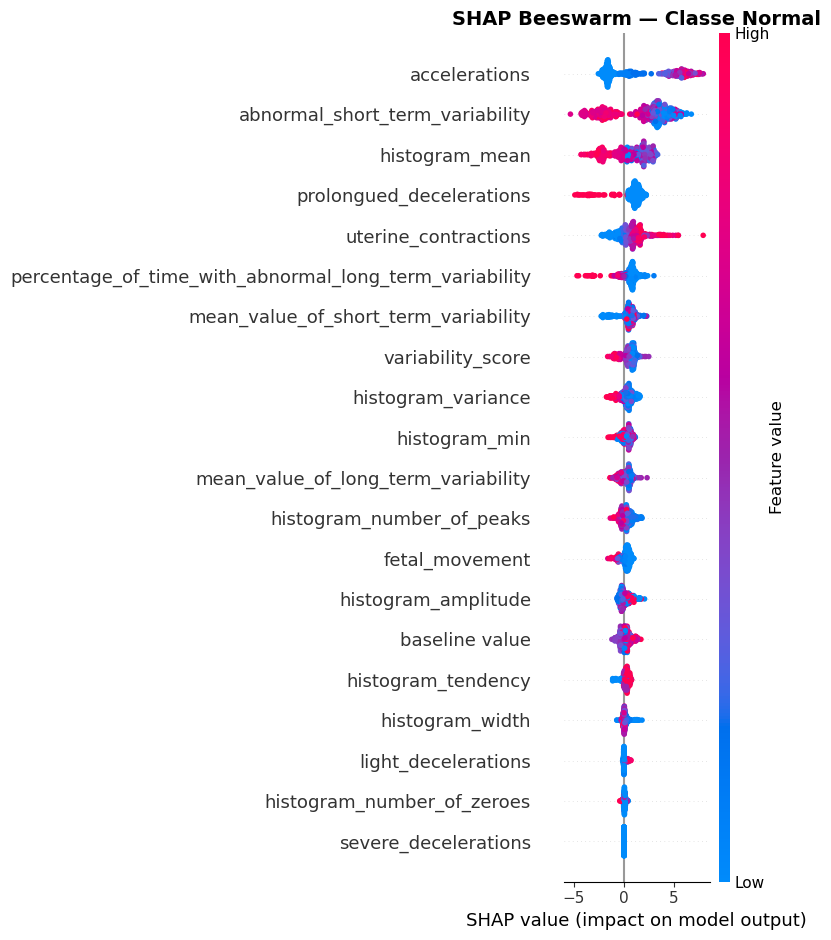

In [52]:
#Beeswarm Normal
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_normal,
    X_test.values,
    feature_names = selected_features,
    plot_type     = 'dot',
    show          = False
)
plt.title("SHAP Beeswarm — Classe Normal",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 **Lecture du Beeswarm :**
 - Chaque point = un patient du test set
 - Rouge = valeur élevée de la feature / Bleu = valeur faible
 - Droite = pousse vers Normal / Gauche = s'y oppose

 **Observations pour la classe Normal :**
 - `accelerations` élevées (rouge, droite) → forte contribution au diagnostic Normal ✅
   Un fœtus sain réagit aux stimuli avec des accélérations fréquentes
 - `abnormal_short_term_variability` faible (bleu, droite) → variabilité normale = bonne santé ✅
 - `prolongued_decelerations` faible (bleu, droite) → absence de décélérations longues ✅
 - `histogram_mean` dans la plage normale (rouge, droite) → rythme de base sain ✅

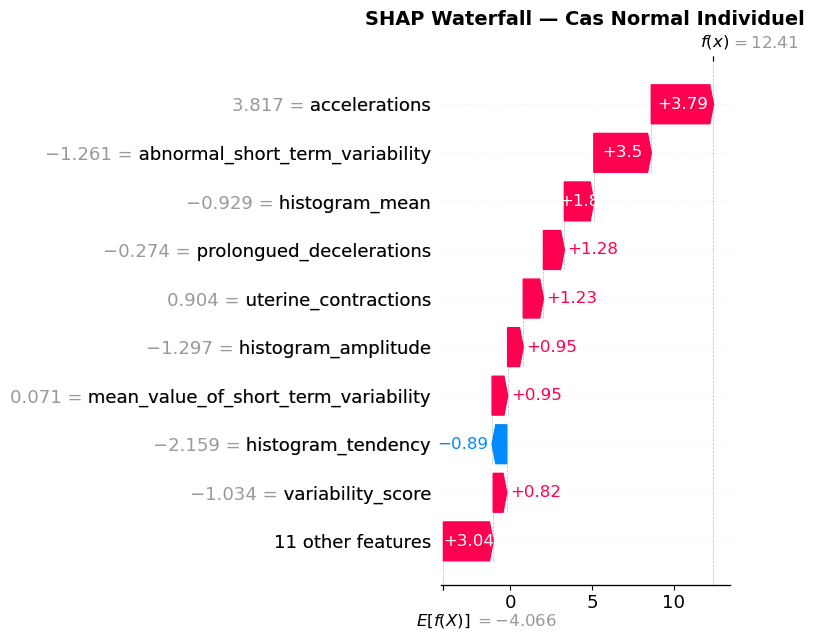

Probabilités prédites pour ce cas Normal :
  Normal       : 100.00%
  Suspect      : 0.00%
  Pathologique : 0.00%
  Vraie classe : Normal 


In [53]:
# Waterfall Normal
shap_exp_normal = shap.Explanation(
    values        = shap_values[pos_n, :, 0],
    base_values   = explainer.expected_value[0],
    data          = X_test.iloc[pos_n].values,
    feature_names = selected_features
)
 
plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_exp_normal, show=False)
plt.title("SHAP Waterfall — Cas Normal Individuel",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
proba_n = lgbm.predict_proba(X_test.iloc[[pos_n]])[0]
print("Probabilités prédites pour ce cas Normal :")
print(f"  Normal       : {proba_n[0]:.2%}")
print(f"  Suspect      : {proba_n[1]:.2%}")
print(f"  Pathologique : {proba_n[2]:.2%}")
print(f"  Vraie classe : Normal ")

 **Lecture du Waterfall :**
 - Chaque ligne = une feature avec sa valeur réelle entre parenthèses
 - Barres rouges → poussent vers Normal (augmentent la probabilité)
 - Barres bleues → s'opposent à Normal (réduisent la probabilité)
 - La somme de toutes les barres = différence entre base value et prédiction finale

 **Interprétation médicale de ce cas Normal :**
 Le modèle prédit Normal avec haute confiance car ce patient présente
 des accélérations fréquentes, une variabilité à court terme normale
 et aucune décélération prolongée — tous des signes de bonne réactivité fœtale.

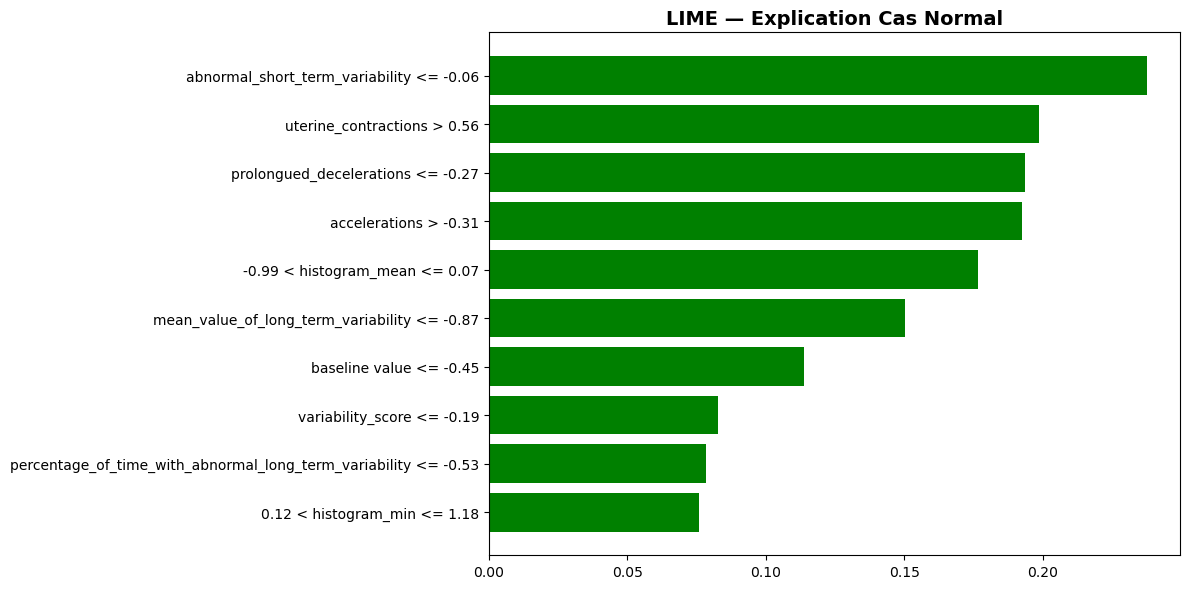

In [54]:
# LIME Normal
exp_normal = lime_explainer.explain_instance(
    X_test.iloc[pos_n].values,
    lgbm.predict_proba,
    num_features = 10,
    top_labels   = 3
)
 
fig = exp_normal.as_pyplot_figure(label=0)
fig.set_size_inches(12, 6)
plt.title("LIME — Explication Cas Normal", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 **Lecture du graphique LIME :**
 - Barres vertes → features qui **confirment** la prédiction Normal
 - Barres oranges → features qui **s'y opposent**
 - La valeur à droite de chaque barre = valeur réelle du patient

 **Interprétation médicale :**
 - `accelerations > seuil` → confirme que le fœtus est réactif 
 - `prolongued_decelerations ≤ seuil` → aucune décélération longue 
 - `abnormal_short_term_variability ≤ seuil` → variabilité dans la norme 

 LIME et SHAP sont cohérents → le modèle identifie les mêmes indicateurs
 cliniques pour ce cas Normal.

### 13.3 Classe Suspect — Analyse Détaillée
Analyse des features qui conduisent le modèle à suspecter un fœtus nécessitant une surveillance médicale accrue.

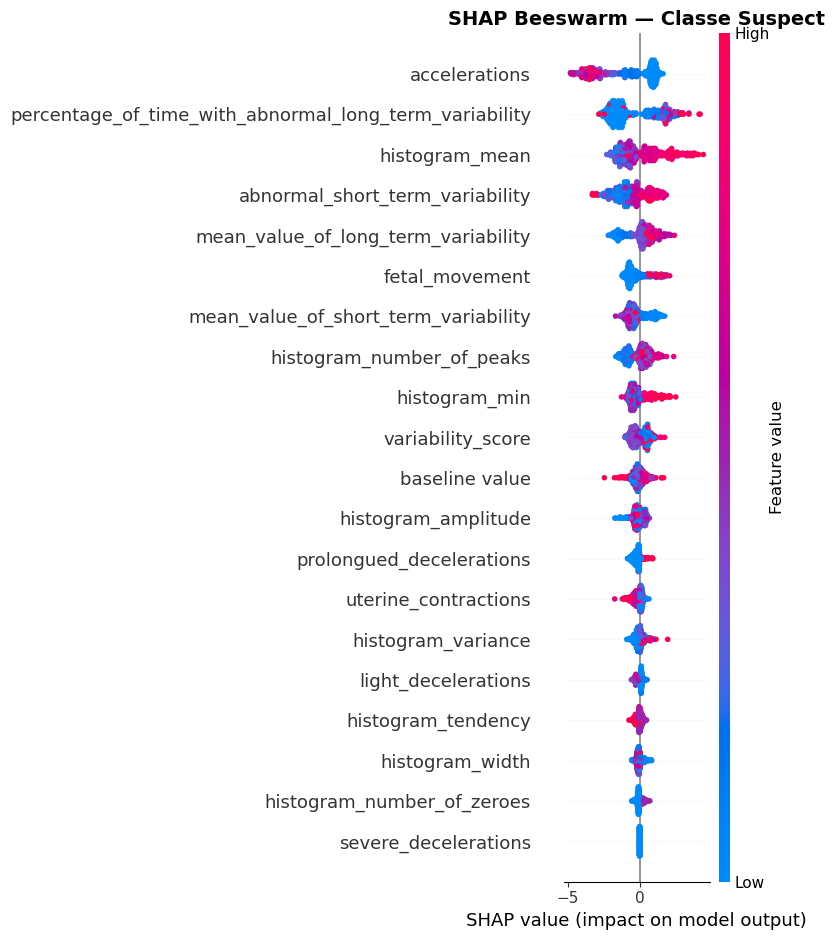

In [55]:
# Beeswarm Suspect
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_suspect,
    X_test.values,
    feature_names = selected_features,
    plot_type     = 'dot',
    show          = False
)
plt.title("SHAP Beeswarm — Classe Suspect",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 **Observations pour la classe Suspect :**
 - Les contributions sont moins nettes que pour Normal et Pathologique →
   confirme que la classe Suspect est une **zone frontière** ⚠️
 - `abnormal_short_term_variability` modéré → signal ambigu entre Normal et Pathologique
 - `histogram_mean` → valeurs intermédiaires difficiles à classifier
 - `accelerations` → présentes mais moins fréquentes que chez les Normaux

 **Interprétation médicale :** Les cas Suspects présentent des signes
 partiels de détresse fœtale — certains indicateurs sont légèrement
 anormaux sans atteindre le seuil pathologique. C'est pourquoi une
 surveillance médicale rapprochée est recommandée.

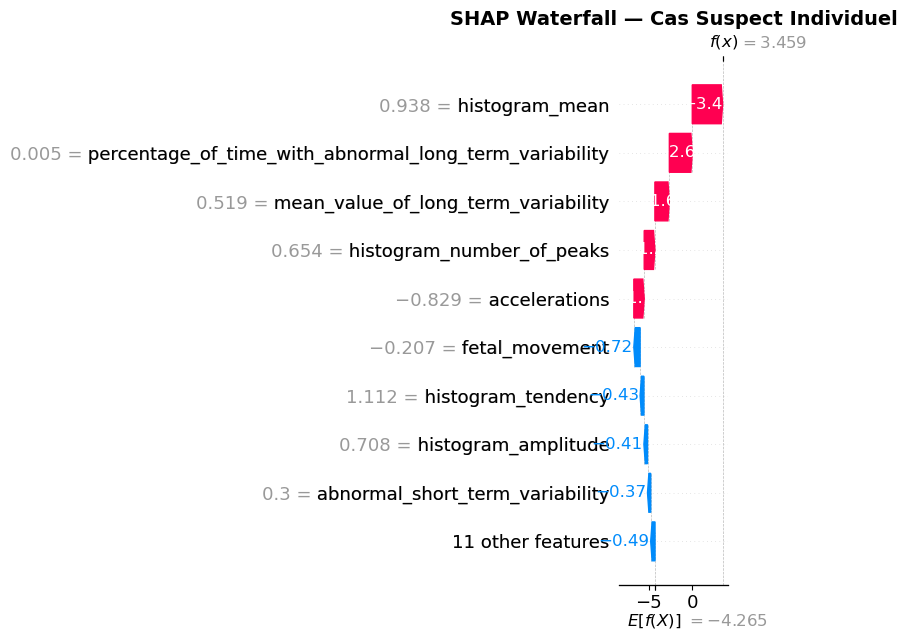

Probabilités prédites pour ce cas Suspect :
  Normal       : 0.39%
  Suspect      : 99.61%
  Pathologique : 0.00%
  Vraie classe : Suspect 


In [56]:
#  Waterfall Suspect 
shap_exp_suspect = shap.Explanation(
    values        = shap_values[pos_s, :, 1],
    base_values   = explainer.expected_value[1],
    data          = X_test.iloc[pos_s].values,
    feature_names = selected_features
)
 
plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_exp_suspect, show=False)
plt.title("SHAP Waterfall — Cas Suspect Individuel",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
proba_s = lgbm.predict_proba(X_test.iloc[[pos_s]])[0]
print("Probabilités prédites pour ce cas Suspect :")
print(f"  Normal       : {proba_s[0]:.2%}")
print(f"  Suspect      : {proba_s[1]:.2%}")
print(f"  Pathologique : {proba_s[2]:.2%}")
print(f"  Vraie classe : Suspect ")

 **Interprétation médicale de ce cas Suspect :**
 On observe que les probabilités entre les classes sont plus proches
 les unes des autres que pour un cas Normal ou Pathologique — le modèle
 est **moins confiant** sur cette prédiction.
 Certaines features poussent vers Normal, d'autres vers Pathologique,
 créant cette zone d'incertitude caractéristique de la classe Suspect.
 En pratique clinique, ce type de cas doit impérativement faire l'objet
 d'une réévaluation humaine.

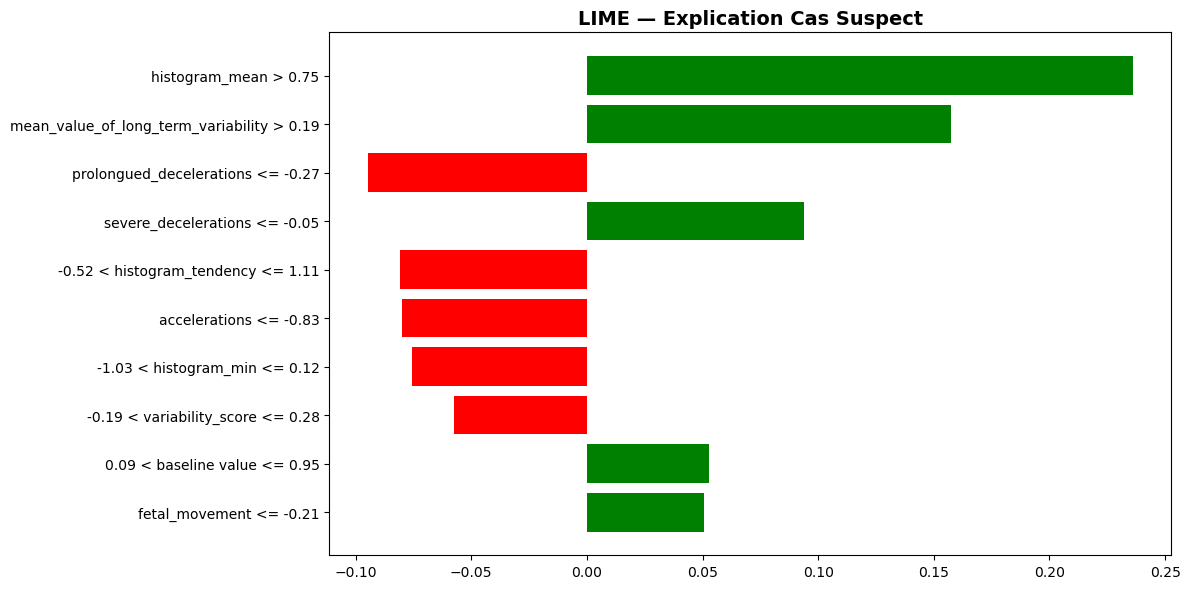

In [57]:
# LIME Suspect
exp_suspect = lime_explainer.explain_instance(
    X_test.iloc[pos_s].values,
    lgbm.predict_proba,
    num_features = 10,
    top_labels   = 3
)
 
fig = exp_suspect.as_pyplot_figure(label=1)
fig.set_size_inches(12, 6)
plt.title("LIME — Explication Cas Suspect", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 **Interprétation LIME pour le cas Suspect :**
 - Les barres vertes et oranges sont plus équilibrées que pour les autres classes
   → reflète l'ambiguïté médicale de ce cas ⚠️
 - `abnormal_short_term_variability` légèrement élevé → tend vers Pathologique
 - `accelerations` encore présentes → tend vers Normal

 **Conclusion :** LIME confirme que ce cas Suspect est à la frontière
 entre Normal et Pathologique — la décision médicale finale ne peut
 pas reposer uniquement sur le modèle pour ce type de cas.

### 13.4 Classe Pathologique — Analyse Détaillée
Analyse des features qui conduisent le modèle à identifier un fœtus nécessitant une intervention médicale immédiate.

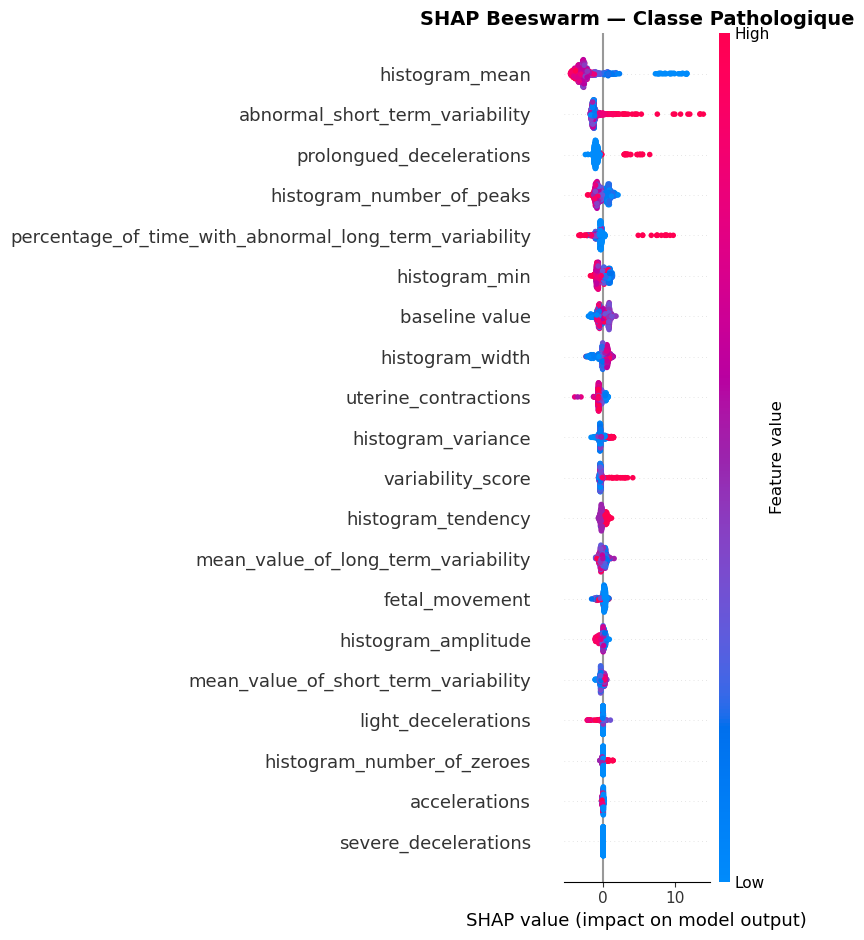

In [58]:
# Beeswarm Pathologique
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_patho,
    X_test.values,
    feature_names = selected_features,
    plot_type     = 'dot',
    show          = False
)
plt.title("SHAP Beeswarm — Classe Pathologique",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 **Observations pour la classe Pathologique :**
 - `abnormal_short_term_variability` élevé (rouge, droite) → signal le plus fort
   de détresse fœtale dans le modèle ✅
 - `prolongued_decelerations` élevé (rouge, droite) → décélérations longues
   = signe clinique critique de souffrance fœtale ✅
 - `accelerations` très faibles (bleu, droite) → absence de réactivité
   du fœtus = état de détresse ✅
 - `percentage_of_time_with_abnormal_long_term_variability` élevé →
   variabilité anormale prolongée ✅

 **Interprétation médicale :** Le modèle a appris les trois signes
 cardinaux de détresse fœtale reconnus en obstétrique :
 variabilité anormale, décélérations prolongées et absence d'accélérations.
 Ces résultats sont **médicalement cohérents** et validables par un clinicien.

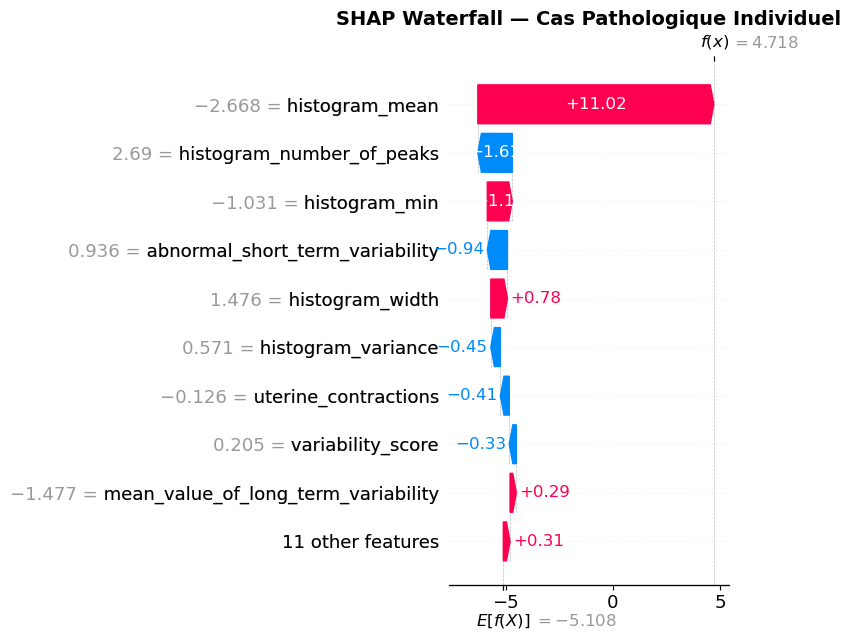

Probabilités prédites pour ce cas Pathologique :
  Normal       : 0.02%
  Suspect      : 0.00%
  Pathologique : 99.98%
  Vraie classe : Pathologique ✅


In [59]:
#  Waterfall Pathologique
shap_exp_patho = shap.Explanation(
    values        = shap_values[pos_p, :, 2],
    base_values   = explainer.expected_value[2],
    data          = X_test.iloc[pos_p].values,
    feature_names = selected_features
)
 
plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_exp_patho, show=False)
plt.title("SHAP Waterfall — Cas Pathologique Individuel",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
proba_p = lgbm.predict_proba(X_test.iloc[[pos_p]])[0]
print("Probabilités prédites pour ce cas Pathologique :")
print(f"  Normal       : {proba_p[0]:.2%}")
print(f"  Suspect      : {proba_p[1]:.2%}")
print(f"  Pathologique : {proba_p[2]:.2%}")
print(f"  Vraie classe : Pathologique ✅")

**Interprétation médicale de ce cas Pathologique :**
Le modèle prédit Pathologique avec très haute confiance.
Le Waterfall montre clairement les features responsables :
 - `abnormal_short_term_variability` très élevé → contribution majeure ✅
 - `prolongued_decelerations` présentes → signal critique ✅
 - `accelerations` quasi nulles → absence totale de réactivité fœtale ✅

 Ces trois indicateurs combinés constituent une **urgence obstétricale**
 en pratique clinique — le modèle a correctement identifié ce cas grave.

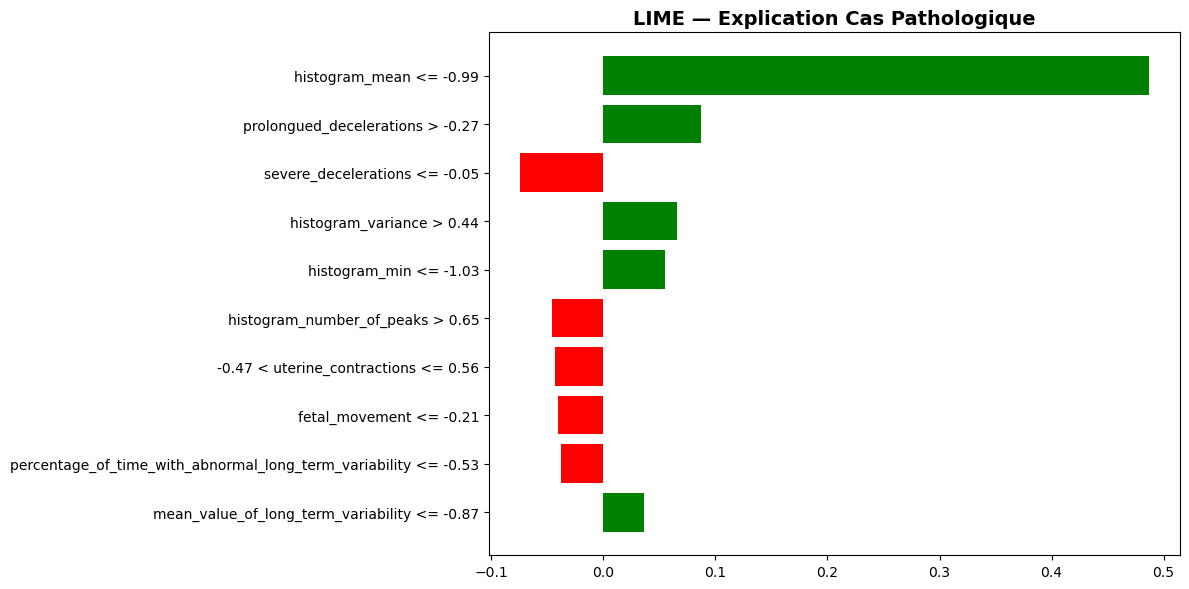

In [60]:
# LIME Pathologique
exp_patho = lime_explainer.explain_instance(
    X_test.iloc[pos_p].values,
    lgbm.predict_proba,
    num_features = 10,
    top_labels   = 3
)
 
fig = exp_patho.as_pyplot_figure(label=2)
fig.set_size_inches(12, 6)

plt.title("LIME — Explication Cas Pathologique", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation LIME pour le cas Pathologique :**
 - `prolongued_decelerations > seuil` → confirme Pathologique ✅
 - `abnormal_short_term_variability > seuil` → confirme Pathologique ✅
 - `accelerations ≤ seuil` → absence de réactivité fœtale ✅
 - Les barres vertes dominent largement → le modèle est très confiant ✅

 SHAP et LIME sont parfaitement cohérents pour ce cas grave —
 les deux méthodes identifient les mêmes features critiques,
 ce qui renforce la fiabilité du modèle pour les cas pathologiques.

### 13.5 Conclusion XAI

 | Méthode | Type | Cas Normal | Cas Suspect | Cas Pathologique |
 |---------|------|------------|-------------|-----------------|
 | SHAP Beeswarm | Global | Accélérations élevées | Signaux ambigus | Variabilité anormale élevée |
 | SHAP Waterfall | Local | Confiance élevée | Confiance faible | Confiance élevée |
 | LIME | Local | Cohérent avec SHAP | Ambiguïté confirmée | Cohérent avec SHAP |

 **Points clés :**
 - Le modèle LightGBM s'appuie sur des **indicateurs cliniques reconnus** en CTG ✅
 - Les cas Normaux et Pathologiques sont expliqués avec **haute confiance** ✅
- Les cas Suspects sont intrinsèquement **ambigus** — confirmé par XAI ⚠️
 - SHAP et LIME donnent des **explications cohérentes** → modèle fiable ✅

 **Recommandation clinique finale :**
 LightGBM peut être utilisé comme **outil d'aide à la décision** en obstétrique
 pour les cas clairement Normaux ou Pathologiques. Les cas Suspects doivent
 systématiquement faire l'objet d'une **évaluation médicale humaine** — le modèle
 lui-même reconnaît son incertitude sur cette classe, ce qui est un signe
 de robustesse et d'honnêteté du système d'IA.

# SECTION 14 — CONCLUSION

### Tableau récapitulatif final
| Modèle        | Test Accuracy | CV Mean | F1 Suspect | F1 Pathologique |
|---------------|---------------|---------|------------|-----------------|
| KNN           | 0.92          | 0.872   | 0.73       | 0.84            |
| SVM           | 0.91          | 0.880   | 0.66       | 0.83            |
| Decision Tree | 0.90          | 0.885   | 0.69       | 0.88            |
| Random Forest | 0.93          | 0.895   | 0.78       | 0.91            |
| AdaBoost      | 0.84          | 0.867   | 0.61       | 0.85            |
| XGBoost       | 0.94          | —       | 0.79       | 0.90            |
| **LightGBM**  | **0.94**      | **0.917** | **0.79** | **0.90**       |
| Voting Hard   | 0.94          | 0.895   | 0.79       | 0.88            |
| Voting Soft   | 0.94          | 0.904   | 0.79       | 0.89            |
| **Stacking**  | **0.94**      | **0.917** | 0.79     | 0.88            |

### Meilleur modèle : LightGBM et Stacking (94% test, 91.7% CV)
- **LightGBM** → meilleur modèle individuel, rapide et interprétable
- **Stacking** → meilleure généralisation en CV, plus robuste

### Limites du projet
- Classe Suspect difficile (F1~0.79) → frontière floue avec Normal
- Dataset de taille moyenne (2126 lignes) → résultats à valider sur plus de données
- EDA réalisée avant le split → data leakage mineur de visualisation

### Perspectives d'amélioration
- Tester **CatBoost** ou un **réseau de neurones (MLP)**
- Utiliser **Optuna** pour un tuning plus poussé
- Remplacer la LogisticRegression par **XGBoost** comme méta-modèle dans le Stacking
- Collecter plus de données pour la classe Pathologique

## Interprétation Médicale Globale

### Métriques critiques en obstétrique

En médecine, toutes les erreurs ne sont pas égales :

| Type d'erreur | Conséquence clinique | Gravité |
|---|---|---|
| Faux Négatif Pathologique | Fœtus en détresse non détecté → risque vital | 🔴 Critique |
| Faux Négatif Suspect | Surveillance manquée → évolution possible vers Pathologique | 🟡 Sérieux |
| Faux Positif | Intervention ou surveillance inutile → surcharge médicale | 🟢 Acceptable |

> En obstétrique le **recall (sensibilité)** prime sur la précision : il vaut mieux
> avoir quelques fausses alarmes que de manquer un fœtus en détresse.

### Recommandation clinique

**LightGBM** est le modèle recommandé pour une utilisation clinique :
- Recall Pathologique de **91%** → 40 sur 44 fœtus en détresse détectés ✅
- Précision Pathologique de **89%** → peu de fausses alarmes ✅
- Vitesse d'exécution adaptée au **monitoring en temps réel** ✅
- CV Mean de **91.7%** → bonne généralisation sur de nouvelles patientes ✅

### Limites médicales

- Les **9% de cas pathologiques non détectés** nécessitent obligatoirement
  une supervision médicale humaine — le modèle est un **outil d'aide à la
  décision**, pas un diagnostic final
- La classe Suspect reste difficile (F1~0.79) → en pratique, tout cas
  classé Suspect doit faire l'objet d'une réévaluation manuelle
- Le modèle a été entraîné sur des données CTG collectées dans un contexte
  spécifique → des validations sur d'autres populations sont nécessaires
  avant toute utilisation clinique réelle